In [1]:
import os, platform, requests

# força UTF-8 no Python
os.environ["PYTHONUTF8"] = "1"
os.environ["PYTHONIOENCODING"] = "utf-8"

# locale pro R
os.environ["LC_ALL"] = "C.UTF-8"
os.environ["LANG"] = "C.UTF-8"

# R_HOME explícito
os.environ["R_HOME"] = r"C:\Program Files\R\R-4.5.1"

In [2]:
import pandas as pd
import numpy as np
from bcb import currency
from statistics import mode
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [3]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

# **CARREGAR R E BIBLIOTECAS**

In [4]:
#Apontar para a pasta certa
ro.r('.libPaths("C:/Users/FábioGaldino/AppData/Local/R/win-library/4.5")')

# Forçar locale e encoding para UTF-8
ro.r('options(encoding = "latin1")')
so = platform.system()
if so == "Windows":
    ro.r('Sys.setlocale("LC_ALL", "Portuguese_Brazil.1252")')
else:
    ro.r('Sys.setlocale("LC_ALL", "pt_BR.UTF-8")')

# Carregar pacotes
ro.r('suppressPackageStartupMessages(library(utils))')
ro.r('suppressPackageStartupMessages(library(tsibbledata))')
ro.r('suppressPackageStartupMessages(library(fpp3))')
ro.r('suppressPackageStartupMessages(library(dplyr))')
ro.r('suppressPackageStartupMessages(library(ggtime))')
ro.r('suppressPackageStartupMessages(library(patchwork))')
ro.r('suppressPackageStartupMessages(library(gridExtra))')
ro.r('suppressPackageStartupMessages(library(GGally))')
ro.r('suppressPackageStartupMessages(library(lubridate))')

%load_ext rpy2.ipython

In [5]:
%%R
options(tibble.width = Inf)
options(width = 1600)

In [6]:
def tsibble_df(name):
    with localconverter(ro.default_converter + pandas2ri.converter):
        return ro.conversion.rpy2py(ro.r(name))

In [7]:
def df_tsibble(df, index, name, key=None):
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv[name] = ro.conversion.py2rpy(df)

    ro.r(f"{name}$`{index}` <- tsibble::yearmonth({name}$`{index}`)")

    if key:
        r_cmd = f"{name} <- tsibble::as_tsibble({name}, index = `{index}`, key = {key})"
    else:
        r_cmd = f"{name} <- tsibble::as_tsibble({name}, index = `{index}`)"

    ro.r(r_cmd)

    ro.r(f"print({name})")

In [8]:
corDefault = "#6688AA"
corViridis = ['#440154', '#414487', '#2a788e', '#22a884', '#7ad151']

def set_plot_style():
    # Background colors
    plt.figure().patch.set_facecolor("0.85")
    plt.axes().set(facecolor="0.85")
    
    # Hiding grid
    plt.grid(False)
    
    # Setting only left and bottom spines as visible
    ax = plt.gca()
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Spines color
    ax.spines['bottom'].set_color("black")
    ax.spines['left'].set_color("black")
    
    # Plot size
    plt.gcf().set_size_inches(6, 5)

    # Plot Style
    plt.style.use('seaborn-v0_8-colorblind')

# **IMPORTAÇÃO**

In [9]:
precos = pd.read_excel(
    '../dados/brutos/precos_produtos.xlsx',
    dtype = {
        "IdProduto": "int64",
        "NomeMQEstat": "string",
        "GrupoIA": "string",
        "valor": "float64",
        "IdEdicao": "string",
        "Mes": "string"
    }
)

precos['Mes'] = precos['Mes'].str.strip()
precos = precos.rename(columns = {'Mes': 'ano_mes', 'valor': 'preco_venda_brl'})
precos.head()

,IdProduto,NomeMQEstat,GrupoIA,preco_venda_brl,IdEdicao,ano_mes
0,35,Aminol 806,"2,4-D AE 670",13.825234,448,2020-02
1,35,Aminol 806,"2,4-D AE 670",14.052825,446,2020-01
2,35,Aminol 806,"2,4-D AE 670",14.161839,550,2024-07
3,35,Aminol 806,"2,4-D AE 670",14.320463,548,2024-06
4,35,Aminol 806,"2,4-D AE 670",14.363840,546,2024-05


In [10]:
precos['GrupoIA'] = precos['GrupoIA'].str.upper()
precos['GrupoIA'] = np.where(
    precos['GrupoIA'].str.contains("GLYPHOSATE"),
    "GLYPHOSATE AE 500/720",
    precos['GrupoIA']
)

precos

,IdProduto,NomeMQEstat,GrupoIA,preco_venda_brl,IdEdicao,ano_mes
0,35,Aminol 806,"2,4-D AE 670",13.825234,448,2020-02
1,35,Aminol 806,"2,4-D AE 670",14.052825,446,2020-01
2,35,Aminol 806,"2,4-D AE 670",14.161839,550,2024-07
3,35,Aminol 806,"2,4-D AE 670",14.320463,548,2024-06
4,35,Aminol 806,"2,4-D AE 670",14.363840,546,2024-05
...,...,...,...,...,...,...
5942,4554,Glyphosate AE 720 Post-Patent,GLYPHOSATE AE 500/720,139.199997,500,2022-05
5943,4554,Glyphosate AE 720 Post-Patent,GLYPHOSATE AE 500/720,142.107849,494,2022-02
5944,4554,Glyphosate AE 720 Post-Patent,GLYPHOSATE AE 500/720,149.000000,502,2022-06
5945,4554,Glyphosate AE 720 Post-Patent,GLYPHOSATE AE 500/720,150.223999,500,2022-05


In [11]:
produtos = pd.read_excel(
    '../dados/brutos/produtos_codigos.xlsx',
    dtype = {
        "IdProduto": "int64",
        "NomeMQEstat": "string",
        "GrupoIA": "string",
        "codigo_ncm": "int64"
    }
)

produtos

,IdProduto,NomeMQEstat,GrupoIA,codigo_ncm
0,35,Aminol 806,"2,4-D AE 670",29221912
1,376,U 46 BR,"2,4-D AE 670",29221912
2,475,Roundup WG,glyphosate AE 720,38089324
3,1319,Manzate 750 WG,mancozeb 750,38249986
4,2560,Zapp QI 620,glyphosate AE 500,38089324
5,2734,Poquer,clethodim 240,29309039
6,2741,2 4-D Nortox,"2,4-D AE 670",29221912
7,3026,Unizeb Gold,mancozeb 750,38249986
8,4440,Clethodim 240 Post-Patent,clethodim 240,29309039
9,4554,Glyphosate AE 720 Post-Patent,glyphosate AE 720,38089324


In [12]:
produtos['GrupoIA'] = produtos['GrupoIA'].str.upper()
produtos['GrupoIA'] = np.where(
    produtos['GrupoIA'].str.contains("GLYPHOSATE"),
    "GLYPHOSATE AE 500/720",
    produtos['GrupoIA']
)

produtos

,IdProduto,NomeMQEstat,GrupoIA,codigo_ncm
0,35,Aminol 806,"2,4-D AE 670",29221912
1,376,U 46 BR,"2,4-D AE 670",29221912
2,475,Roundup WG,GLYPHOSATE AE 500/720,38089324
3,1319,Manzate 750 WG,MANCOZEB 750,38249986
4,2560,Zapp QI 620,GLYPHOSATE AE 500/720,38089324
5,2734,Poquer,CLETHODIM 240,29309039
6,2741,2 4-D Nortox,"2,4-D AE 670",29221912
7,3026,Unizeb Gold,MANCOZEB 750,38249986
8,4440,Clethodim 240 Post-Patent,CLETHODIM 240,29309039
9,4554,Glyphosate AE 720 Post-Patent,GLYPHOSATE AE 500/720,38089324


In [13]:
cotacao_dolar = currency.get(
    'USD',
    start = '2020-01-01',
    end = '2025-12-31',
    side = 'ask'
)

cotacao_dolar = cotacao_dolar.reset_index()
cotacao_dolar.columns = ['data', 'dolar']

cotacao_dolar['ano_mes'] = cotacao_dolar['data'].dt.strftime('%Y-%m')

cotacao_dolar = cotacao_dolar.groupby('ano_mes')[['dolar']].mean().reset_index()

cotacao_dolar.head()

,ano_mes,dolar
0,2020-01,4.149464
1,2020-02,4.341011
2,2020-03,4.883855
3,2020-04,5.325580
4,2020-05,5.643445


# **IMPORTAÇÃO COMEX STAT**

In [14]:
url = "https://api-comexstat.mdic.gov.br/general"

headers = {
    "Content-Type": "application/json",
    "Accept": "application/json"
}

## **SISTEMA NCM**

Segundo a [Fazcomex](https://www.fazcomex.com.br/ncm/o-que-e-onde-consultar/), uma startup de tecnologia para comércio exterior, a NCM permite a identificação padronizada das mercadorias comercializadas no Mercosul, ou seja todo produto possui uma NCM.

Separada em várias seções, a que nos interessa é a seção VI: Produtos das Indústrias Químicas ou das Indústrias Conexas.
Nela temos dois capítulos que interessam esta análise:
- Capítulo 29 - Produtos Químicos Orgânicos;
- Capítulo 38 - Produtos diversos das indústrias químicas.

Sendo que o Capítulo 29 [inclui apenas os compostos de constituição química definida apresentados isoladamente](https://www.remessaonline.com.br/blog/ncm/capitulo/29-produtos-quimicos-organicos/).
<br>E o Capítulo 38 [pode conter tanto o ingretiente ativo técnico (38.24) ou o produjo já formulado (38.08)](https://www.remessaonline.com.br/blog/ncm/capitulo/38-produtos-diversos-das-industrias-quimicas/).

<br>

## **2,4-D AE 670: ÁCIDO DE 2,4-D 670 g/L**

Segundo a [Revista Cultivar](https://revistacultivar.com.br/fitossanidade/2-4-d), o ácido 2,4-diclorofenoxiacético, conhecido mundialmente pela sigla **2,4-D**, representa um dos herbicidas auxínicos mais importantes e amplamente utilizados na agricultura moderna.

O Brasil importa este ingrediente ativo tanto como composto de constuição química isolada (NCM 29.18.99.1.2), tanto como em produto já formulado (NCM 38.08.93.2.2):
- 29.18.99.1.2 - Ácido 2,4-diclorofenoxiacético (2,4-D), seus sais e seus ésteres;
- 38.08.93.2.2 - Outros herbicidas apresentados de outro modo, à base de ácido 2,4-diclorofenoxiacético (2,4-D), de ácido 4-(2,4-diclorofenoxi)butírico (2,4-DB), de ácido (4-cloro-2-metil)fenoxiacético (MCPA) ou de derivados de 2,4-D ou 2,4-DB.

In [15]:
payload = {
    "flow": "import",
    "monthDetail": True,
    "period": {
        "from": "2020-01",
        "to": "2025-12"
    },
    "filters": [
        {
            "filter": "ncm",
            "values": ["29189912", "38089322"]
        }
    ],
    "details": ["ncm", "country"],
    "metrics": ["metricFOB", "metricKG"]
}

response = requests.post(url, json=payload, headers=headers, verify=False)

In [16]:
importacao = pd.DataFrame(response.json()['data']['list'])
importacao.columns = ['codigo_ncm', 'ano', 'mes', 'descricao', 'pais', 'valor_usd', 'volume']
importacao['volume'] = pd.to_numeric(importacao['volume'])
importacao['valor_usd'] = pd.to_numeric(importacao['valor_usd'])
importacao['GrupoIA'] = "2,4-D AE 670"

importacao.head()

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA
0,38089322,2025,09,"Outros herbicidas apresentados de outro modo, ...",China,12296818,7903457,"2,4-D AE 670"
1,38089322,2025,11,"Outros herbicidas apresentados de outro modo, ...",China,11302287,5486426,"2,4-D AE 670"
2,38089322,2025,07,"Outros herbicidas apresentados de outro modo, ...",China,11294664,7470170,"2,4-D AE 670"
3,38089322,2025,08,"Outros herbicidas apresentados de outro modo, ...",China,9547710,6732323,"2,4-D AE 670"
4,38089322,2025,12,"Outros herbicidas apresentados de outro modo, ...",China,9113941,5523313,"2,4-D AE 670"


## **GLYPHOSATE AE 500/720: ÁCIDO DE N-(FOSFONOMETIL)GLICINA 500/720 g/kg**

O [Glifosato](https://revistacultivar.com.br/fitossanidade/glifosato), ácido de N-(fosfonometil)glicina, possui um mecanismo bioquímico que inibe a EPSPS, atuando no controle de plantas daninhas nas lavouras agrícolas.

Também é importado como composto de constuição química isolada (NCM 29.31.49.1.4) e como produto já formulado (NCM 38.08.93.2.4):
- 29.31.49.1.4 - Glifosato e seu sal de monoisopropilamina;
- 38.08.93.2.4 - Herbicida à base de glifosato ou seus sais, de imazaquim ou de lactofen.

In [17]:
payload = {
    "flow": "import",
    "monthDetail": True,
    "period": {
        "from": "2020-01",
        "to": "2025-12"
    },
    "filters": [
        {
            "filter": "ncm",
            "values": ["29314914", "38089324"]
        }
    ],
    "details": ["ncm", "country"],
    "metrics": ["metricFOB", "metricKG"]
}

response = requests.post(url, json=payload, headers=headers, verify=False)

In [18]:
df = pd.DataFrame(response.json()['data']['list'])
df.columns = ['codigo_ncm', 'ano', 'mes', 'descricao', 'pais', 'valor_usd', 'volume']
df['volume'] = pd.to_numeric(df['volume'])
df['valor_usd'] = pd.to_numeric(df['valor_usd'])
df['GrupoIA'] = "GLYPHOSATE AE 500/720"

importacao = pd.concat([importacao, df], axis = 0, ignore_index = True)
importacao

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA
0,38089322,2025,09,"Outros herbicidas apresentados de outro modo, ...",China,12296818,7903457,"2,4-D AE 670"
1,38089322,2025,11,"Outros herbicidas apresentados de outro modo, ...",China,11302287,5486426,"2,4-D AE 670"
2,38089322,2025,07,"Outros herbicidas apresentados de outro modo, ...",China,11294664,7470170,"2,4-D AE 670"
3,38089322,2025,08,"Outros herbicidas apresentados de outro modo, ...",China,9547710,6732323,"2,4-D AE 670"
4,38089322,2025,12,"Outros herbicidas apresentados de outro modo, ...",China,9113941,5523313,"2,4-D AE 670"
...,...,...,...,...,...,...,...,...
864,38089324,2020,09,"Herbicida à base de glifosato ou seus sais, de...",Taiwan (Formosa),586804,409180,GLYPHOSATE AE 500/720
865,38089324,2020,03,"Herbicida à base de glifosato ou seus sais, de...",China,328401,108000,GLYPHOSATE AE 500/720
866,38089324,2020,06,"Herbicida à base de glifosato ou seus sais, de...",Taiwan (Formosa),295726,210600,GLYPHOSATE AE 500/720
867,38089324,2020,08,"Herbicida à base de glifosato ou seus sais, de...",Taiwan (Formosa),147201,105300,GLYPHOSATE AE 500/720


## **MANCOZEB 750: MANCOZEBE 750 g/kg**

O [Mancozebe](https://revistacultivar.com.br/fitossanidade/mancozebe) é um fungicida de contato amplamente utilizado no controle preventivo de doenças fúngicas em diversas culturas agrícolas.

Sua importação se dá como ingretiente ativo técnico (NMC 38.24.99.8.6) ou o produjo já formulado (NCM 38.08.92.9.3):
- 38.24.99.8.6 - Maneb; mancozeb; cloreto de benzalcônio;
- 38.08.92.9.3 - Fungicida à base de mancozeb ou de maneb.

In [19]:
payload = {
    "flow": "import",
    "monthDetail": True,
    "period": {
        "from": "2020-01",
        "to": "2025-12"
    },
    "filters": [
        {
            "filter": "ncm",
            "values": ["38249986", "38089293"]
        }
    ],
    "details": ["ncm", "country"],
    "metrics": ["metricFOB", "metricKG"]
}

response = requests.post(url, json=payload, headers=headers, verify=False)

In [20]:
df = pd.DataFrame(response.json()['data']['list'])
df.columns = ['codigo_ncm', 'ano', 'mes', 'descricao', 'pais', 'valor_usd', 'volume']
df['volume'] = pd.to_numeric(df['volume'])
df['valor_usd'] = pd.to_numeric(df['valor_usd'])
df['GrupoIA'] = "MANCOZEB 750"

importacao = pd.concat([importacao, df], axis = 0, ignore_index = True)
importacao

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA
0,38089322,2025,09,"Outros herbicidas apresentados de outro modo, ...",China,12296818,7903457,"2,4-D AE 670"
1,38089322,2025,11,"Outros herbicidas apresentados de outro modo, ...",China,11302287,5486426,"2,4-D AE 670"
2,38089322,2025,07,"Outros herbicidas apresentados de outro modo, ...",China,11294664,7470170,"2,4-D AE 670"
3,38089322,2025,08,"Outros herbicidas apresentados de outro modo, ...",China,9547710,6732323,"2,4-D AE 670"
4,38089322,2025,12,"Outros herbicidas apresentados de outro modo, ...",China,9113941,5523313,"2,4-D AE 670"
...,...,...,...,...,...,...,...,...
1353,38249986,2020,09,Maneb; mancozeb; cloreto de benzalcônio,China,911,20,MANCOZEB 750
1354,38249986,2020,03,Maneb; mancozeb; cloreto de benzalcônio,Canadá,852,0,MANCOZEB 750
1355,38249986,2020,12,Maneb; mancozeb; cloreto de benzalcônio,Índia,518,1,MANCOZEB 750
1356,38089293,2020,04,Fungicida à base de mancozeb ou de maneb,China,509,15,MANCOZEB 750


## **CLETHODIM 240: CLETODIM 240 g/L**

O [Cletodim](https://agroadvance.com.br/blog-fitotoxicidade-de-herbicidas-na-soja) é um herbicida graminicida utilizado no controle de gramíneas em culturas de folhas largas, como a soja.

No Brasil é importado como composto de constuição química isolada (NCM 29.30.90.3.9) e [como produto já formulado](https://solucoes.nortox.com.br/hc/pt-br/articles/4404082884116-Cletodim-Nortox) (NCM 38.08.93.2.9):
- 29.30.90.3.9 - Outros tioéteres, tioésteres, seus derivados e sais;
- 38.08.93.2.9 - Outros herbicidas apresentados de outro modo.

In [23]:
payload = {
    "flow": "import",
    "monthDetail": True,
    "period": {
        "from": "2020-01",
        "to": "2025-12"
    },
    "filters": [
        {
            "filter": "ncm",
            "values": ["29309039", "38089329"]
        }
    ],
    "details": ["ncm", "country"],
    "metrics": ["metricFOB", "metricKG"]
}

response = requests.post(url, json=payload, headers=headers, verify=False)

In [25]:
df = pd.DataFrame(response.json()['data']['list'])
df.columns = ['codigo_ncm', 'ano', 'mes', 'descricao', 'pais', 'valor_usd', 'volume']
df['volume'] = pd.to_numeric(df['volume'])
df['valor_usd'] = pd.to_numeric(df['valor_usd'])
df['GrupoIA'] = "CLETHODIM 240"

importacao = pd.concat([importacao, df], axis = 0, ignore_index = True)

importacao['ano_mes'] = importacao['ano'] + "-" + importacao['mes']
importacao['ano'] = pd.to_numeric(importacao['ano'])
importacao['mes'] = pd.to_numeric(importacao['mes'])

importacao

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes
0,38089322,2025,9,"Outros herbicidas apresentados de outro modo, ...",China,12296818,7903457,"2,4-D AE 670",2025-09
1,38089322,2025,11,"Outros herbicidas apresentados de outro modo, ...",China,11302287,5486426,"2,4-D AE 670",2025-11
2,38089322,2025,7,"Outros herbicidas apresentados de outro modo, ...",China,11294664,7470170,"2,4-D AE 670",2025-07
3,38089322,2025,8,"Outros herbicidas apresentados de outro modo, ...",China,9547710,6732323,"2,4-D AE 670",2025-08
4,38089322,2025,12,"Outros herbicidas apresentados de outro modo, ...",China,9113941,5523313,"2,4-D AE 670",2025-12
...,...,...,...,...,...,...,...,...,...
2786,29309039,2020,2,"Outros tioéteres, tioésteres, seus derivados e...",França,79,0,CLETHODIM 240,2020-02
2787,29309039,2020,5,"Outros tioéteres, tioésteres, seus derivados e...",Espanha,49,0,CLETHODIM 240,2020-05
2788,29309039,2020,6,"Outros tioéteres, tioésteres, seus derivados e...",Suíça,41,0,CLETHODIM 240,2020-06
2789,29309039,2020,8,"Outros tioéteres, tioésteres, seus derivados e...",França,4,0,CLETHODIM 240,2020-08


## **TRATAMENTO DE DADOS**

In [26]:
total_por_ing_atv = importacao.groupby('GrupoIA').agg(
    num_registros_total = ('valor_usd', 'count'),
    valor_usd_total = ('valor_usd', 'sum'),
    vol_total = ('volume', 'sum')
).reset_index()

vol_zero = importacao[importacao['volume'] == 0].groupby('GrupoIA').agg(
    num_registros_vol_zero = ('valor_usd', 'count'),
    valor_usd_vol_zero = ('valor_usd', 'sum')
).reset_index()

vol_zero = total_por_ing_atv.merge(vol_zero, on = 'GrupoIA', how = 'left').fillna(0)

vol_zero['pct_vol_zero'] = np.round(vol_zero['num_registros_vol_zero'] / vol_zero['num_registros_total'] * 100, 2)
vol_zero['pct_valor_usd'] = np.round(vol_zero['valor_usd_vol_zero'] / vol_zero['valor_usd_total'] * 100, 5)

vol_zero

,GrupoIA,num_registros_total,valor_usd_total,vol_total,num_registros_vol_zero,valor_usd_vol_zero,pct_vol_zero,pct_valor_usd
0,"2,4-D AE 670",607,1014962403,431782097,45,14590,7.41,0.00144
1,CLETHODIM 240,1433,7390771655,970311498,128,46345,8.93,0.00063
2,GLYPHOSATE AE 500/720,262,4964066945,1008831841,23,3798,8.78,0.00008
3,MANCOZEB 750,489,1733486585,475781187,12,2870,2.45,0.00017


Foram identificados 204 registros (7,4% do total) com volume zerado (metricKG = 0), porém com valor FOB registrado. A proporção varia por ingrediente ativo: Clethodim (8,98%), Glifosato (8,91%), 2,4-D (7,04%) e Mancozeb (2,49%). Em todos os casos, estes registros representam menos de 0,002% do valor total importado por grupo, provavelmente correspondendo a amostras comerciais ou remessas para homologação regulatória. Para o cálculo de preço unitário (USD/kg), estes registros foram excluídos da análise.

In [27]:
importacao = importacao[importacao['volume'] > 0].copy().reset_index(drop = True)
importacao

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes
0,38089322,2025,9,"Outros herbicidas apresentados de outro modo, ...",China,12296818,7903457,"2,4-D AE 670",2025-09
1,38089322,2025,11,"Outros herbicidas apresentados de outro modo, ...",China,11302287,5486426,"2,4-D AE 670",2025-11
2,38089322,2025,7,"Outros herbicidas apresentados de outro modo, ...",China,11294664,7470170,"2,4-D AE 670",2025-07
3,38089322,2025,8,"Outros herbicidas apresentados de outro modo, ...",China,9547710,6732323,"2,4-D AE 670",2025-08
4,38089322,2025,12,"Outros herbicidas apresentados de outro modo, ...",China,9113941,5523313,"2,4-D AE 670",2025-12
...,...,...,...,...,...,...,...,...,...
2578,29309039,2020,6,"Outros tioéteres, tioésteres, seus derivados e...",Dinamarca,1363,100,CLETHODIM 240,2020-06
2579,29309039,2020,4,"Outros tioéteres, tioésteres, seus derivados e...",Taiwan (Formosa),805,200,CLETHODIM 240,2020-04
2580,29309039,2020,8,"Outros tioéteres, tioésteres, seus derivados e...",Estados Unidos,691,3,CLETHODIM 240,2020-08
2581,29309039,2020,3,"Outros tioéteres, tioésteres, seus derivados e...",França,569,1,CLETHODIM 240,2020-03


## **PREÇO IMPORTAÇÃO (R$)**

In [28]:
importacao = importacao.merge(cotacao_dolar, on = 'ano_mes', how = 'left')
importacao['preco_import_brl'] = (importacao['valor_usd'] / importacao['volume']) * importacao['dolar']
importacao['valor_brl'] = importacao['valor_usd'] * importacao['dolar']
importacao = importacao.drop('dolar', axis = 1)
importacao

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes,preco_import_brl,valor_brl
0,38089322,2025,9,"Outros herbicidas apresentados de outro modo, ...",China,12296818,7903457,"2,4-D AE 670",2025-09,8.351036,6.600205e+07
1,38089322,2025,11,"Outros herbicidas apresentados de outro modo, ...",China,11302287,5486426,"2,4-D AE 670",2025-11,11.002399,6.036385e+07
2,38089322,2025,7,"Outros herbicidas apresentados de outro modo, ...",China,11294664,7470170,"2,4-D AE 670",2025-07,8.358906,6.244245e+07
3,38089322,2025,8,"Outros herbicidas apresentados de outro modo, ...",China,9547710,6732323,"2,4-D AE 670",2025-08,7.724770,5.200565e+07
4,38089322,2025,12,"Outros herbicidas apresentados de outro modo, ...",China,9113941,5523313,"2,4-D AE 670",2025-12,8.998069,4.969915e+07
...,...,...,...,...,...,...,...,...,...,...,...
2578,29309039,2020,6,"Outros tioéteres, tioésteres, seus derivados e...",Dinamarca,1363,100,CLETHODIM 240,2020-06,70.829658,7.082966e+03
2579,29309039,2020,4,"Outros tioéteres, tioésteres, seus derivados e...",Taiwan (Formosa),805,200,CLETHODIM 240,2020-04,21.435460,4.287092e+03
2580,29309039,2020,8,"Outros tioéteres, tioésteres, seus derivados e...",Estados Unidos,691,3,CLETHODIM 240,2020-08,1257.904078,3.773712e+03
2581,29309039,2020,3,"Outros tioéteres, tioésteres, seus derivados e...",França,569,1,CLETHODIM 240,2020-03,2778.913236,2.778913e+03


## **PRÉ-PROCESSAMENTO**

In [29]:
importacao_backup = importacao.copy()

In [30]:
importacao.groupby(['GrupoIA', 'ano'])['preco_import_brl'].agg(
    minimo = 'min',
    media = 'mean',
    maximo = 'max',
    std = 'std',
    q25 = lambda x: x.quantile(0.25),
    q50 = lambda x: x.quantile(0.50),
    q75 = lambda x: x.quantile(0.75)
)

minimo       media        maximo          std  \
GrupoIA               ano                                                      
2,4-D AE 670          2020   3.843536   10.988604     15.429098     2.245751   
                      2021   6.799688   12.995968     26.573943     2.883794   
                      2022   8.938238   17.290652     37.322202     4.678996   
                      2023   6.962594   14.861758     37.024955     6.925790   
                      2024   6.768184   22.389683    947.521313   107.570390   
                      2025   7.521804   72.024107   2468.439475   378.850454   
CLETHODIM 240         2020   8.258638  252.767486   5074.344261   676.152938   
                      2021   8.954369  177.836815   2739.531980   332.573211   
                      2022   8.119767  175.062659   2711.711333   312.370788   
                      2023   5.362820  282.196664   5371.114667   626.392277   
                      2024   9.928788  402.533580  12659.482691  1174.479990   
                      2025   9.532696  569.181967  16614.347978  1863.901063   
GLYPHOSATE AE 500/720 2020   6.923107   13.989065     18.821391     4.582212   
                      2021  10.325082   23.657897     46.787621     9.903846   
                      2022   1.118106   37.471408     63.125104    15.375897   
                      2023   1.021572   26.412233     56.339870    13.394505   
                      2024   0.925436   19.948149     33.105347     5.933945   
                      2025   8.211677  113.343124   4089.965727   590.412673   
MANCOZEB 750          2020   7.017780  777.297349  15143.412060  2478.183036   
                      2021  10.312960  943.837803  16857.718758  3065.541085   
                      2022   0.873739  750.464682  10627.694785  2211.456474   
                      2023   0.786423  761.541744  15094.091191  2553.040701   
                      2024   0.898162  755.677388  17716.169068  3027.773854   
                      2025   9.300142  996.626711  18494.304493  3202.218627   

                                  q25        q50         q75  
GrupoIA               ano                                     
2,4-D AE 670          2020   9.779908  11.185139   12.510606  
                      2021  11.232466  13.037441   14.473227  
                      2022  13.961596  16.702738   20.373189  
                      2023   9.723610  12.599573   18.036539  
                      2024   8.267216   9.541031   10.965069  
                      2025   9.936998  10.772612   12.284605  
CLETHODIM 240         2020  34.977046  59.636035  141.134867  
                      2021  31.490511  70.029407  129.122194  
                      2022  36.938614  68.175431  162.362575  
                      2023  34.439561  73.954716  240.078650  
                      2024  31.802940  62.842683  411.340392  
                      2025  33.240618  85.353289  416.910838  
GLYPHOSATE AE 500/720 2020   7.743389  16.415978   17.735224  
                      2021  16.575922  19.316091   27.404933  
                      2022  28.248963  38.079494   48.491126  
                      2023  18.167542  23.608834   31.265788  
                      2024  16.960743  19.408129   21.210010  
                      2025  16.759538  19.330573   21.254131  
MANCOZEB 750          2020  12.603345  16.980814   26.345380  
                      2021  12.816291  17.941369   23.185063  
                      2022  16.172306  20.170248   42.754158  
                      2023  13.488580  17.661530   38.672462  
                      2024  11.958953  15.238786   22.366174  
                      2025  14.729003  17.020039   28.642082

### **2,4-D AE 670**

In [31]:
_24D_df = importacao[(importacao['GrupoIA'] == "2,4-D AE 670")].copy()

In [32]:
_24D_df.groupby(['GrupoIA', 'ano'])['preco_import_brl'].agg(
    minimo = 'min',
    media = 'mean',
    maximo = 'max',
    std = 'std',
    q25 = lambda x: x.quantile(0.25),
    q50 = lambda x: x.quantile(0.50),
    q75 = lambda x: x.quantile(0.75)
)

minimo      media       maximo         std        q25  \
GrupoIA      ano                                                             
2,4-D AE 670 2020  3.843536  10.988604    15.429098    2.245751   9.779908   
             2021  6.799688  12.995968    26.573943    2.883794  11.232466   
             2022  8.938238  17.290652    37.322202    4.678996  13.961596   
             2023  6.962594  14.861758    37.024955    6.925790   9.723610   
             2024  6.768184  22.389683   947.521313  107.570390   8.267216   
             2025  7.521804  72.024107  2468.439475  378.850454   9.936998   

                         q50        q75  
GrupoIA      ano                         
2,4-D AE 670 2020  11.185139  12.510606  
             2021  13.037441  14.473227  
             2022  16.702738  20.373189  
             2023  12.599573  18.036539  
             2024   9.541031  10.965069  
             2025  10.772612  12.284605

In [33]:
_24D_df[_24D_df['preco_import_brl'] > 50]

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes,preco_import_brl,valor_brl
78,29189912,2025,6,"Ácido 2,4-diclorofenoxiacético (2,4-D), seus s...",Japão,13350,30,"2,4-D AE 670",2025-06,2468.439475,74053.184250
79,29189912,2025,11,"Ácido 2,4-diclorofenoxiacético (2,4-D), seus s...",Japão,8900,20,"2,4-D AE 670",2025-11,2376.679421,47533.588421
154,38089322,2024,9,"Outros herbicidas apresentados de outro modo, ...",Taiwan (Formosa),10943,64,"2,4-D AE 670",2024-09,947.521313,60641.364033


In [34]:
_24D_df = _24D_df[_24D_df['preco_import_brl'] <= 50].copy().reset_index(drop = True)

In [35]:
_24D_df.groupby(['GrupoIA', 'ano'])['preco_import_brl'].agg(
    minimo = 'min',
    media = 'mean',
    maximo = 'max',
    std = 'std',
    q25 = lambda x: x.quantile(0.25),
    q50 = lambda x: x.quantile(0.50),
    q75 = lambda x: x.quantile(0.75)
)

minimo      media     maximo       std        q25  \
GrupoIA      ano                                                         
2,4-D AE 670 2020  3.843536  10.988604  15.429098  2.245751   9.779908   
             2021  6.799688  12.995968  26.573943  2.883794  11.232466   
             2022  8.938238  17.290652  37.322202  4.678996  13.961596   
             2023  6.962594  14.861758  37.024955  6.925790   9.723610   
             2024  6.768184  10.054594  22.400088  2.785203   8.247232   
             2025  7.521804  11.753970  22.422273  3.794605   9.827551   

                         q50        q75  
GrupoIA      ano                         
2,4-D AE 670 2020  11.185139  12.510606  
             2021  13.037441  14.473227  
             2022  16.702738  20.373189  
             2023  12.599573  18.036539  
             2024   9.462658  10.891488  
             2025  10.732201  12.038484

### **CLETHODIM 240**

In [36]:
cletodim_df = importacao[(importacao['GrupoIA'] == "CLETHODIM 240")].copy()

In [37]:
cletodim_df.groupby(['GrupoIA', 'ano'])['preco_import_brl'].agg(
    minimo = 'min',
    media = 'mean',
    maximo = 'max',
    std = 'std',
    q25 = lambda x: x.quantile(0.25),
    q50 = lambda x: x.quantile(0.50),
    q75 = lambda x: x.quantile(0.75)
)

minimo       media        maximo          std  \
GrupoIA       ano                                                     
CLETHODIM 240 2020  8.258638  252.767486   5074.344261   676.152938   
              2021  8.954369  177.836815   2739.531980   332.573211   
              2022  8.119767  175.062659   2711.711333   312.370788   
              2023  5.362820  282.196664   5371.114667   626.392277   
              2024  9.928788  402.533580  12659.482691  1174.479990   
              2025  9.532696  569.181967  16614.347978  1863.901063   

                          q25        q50         q75  
GrupoIA       ano                                     
CLETHODIM 240 2020  34.977046  59.636035  141.134867  
              2021  31.490511  70.029407  129.122194  
              2022  36.938614  68.175431  162.362575  
              2023  34.439561  73.954716  240.078650  
              2024  31.802940  62.842683  411.340392  
              2025  33.240618  85.353289  416.910838

#### **ANÁLISE ANO A ANO**

In [38]:
cletodim_df[(cletodim_df['preco_import_brl'] > 960) & (cletodim_df['ano'] == 2021)]

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes,preco_import_brl,valor_brl
2304,38089329,2021,8,Outros herbicidas apresentados de outro modo,Japão,323937,1296,CLETHODIM 240,2021-08,1312.674254,1.701226e+06
2324,38089329,2021,6,Outros herbicidas apresentados de outro modo,Japão,161946,648,CLETHODIM 240,2021-06,1257.556865,8.148968e+05
2325,38089329,2021,1,Outros herbicidas apresentados de outro modo,Japão,161893,648,CLETHODIM 240,2021-01,1338.176808,8.671386e+05
2370,29309039,2021,10,"Outros tioéteres, tioésteres, seus derivados e...",Japão,12250,25,CLETHODIM 240,2021-10,2714.590200,6.786476e+04
2398,29309039,2021,11,"Outros tioéteres, tioésteres, seus derivados e...",Países Baixos (Holanda),493,1,CLETHODIM 240,2021-11,2739.531980,2.739532e+03


In [39]:
cletodim_df[(cletodim_df['preco_import_brl'] > 960) & (cletodim_df['ano'] == 2022)]

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes,preco_import_brl,valor_brl
2084,38089329,2022,5,Outros herbicidas apresentados de outro modo,Japão,334510,1338,CLETHODIM 240,2022-05,1238.799533,1.657514e+06
2147,29309039,2022,1,"Outros tioéteres, tioésteres, seus derivados e...",Japão,12250,25,CLETHODIM 240,2022-01,2711.711333,6.779278e+04
2168,29309039,2022,8,"Outros tioéteres, tioésteres, seus derivados e...",Países Baixos (Holanda),481,1,CLETHODIM 240,2022-08,2473.921026,2.473921e+03


In [40]:
cletodim_df[(cletodim_df['preco_import_brl'] > 960) & (cletodim_df['ano'] == 2023)]

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes,preco_import_brl,valor_brl
1759,38089329,2023,7,Outros herbicidas apresentados de outro modo,Estados Unidos,18068293,61000,CLETHODIM 240,2023-07,1422.014153,8.674286e+07
1827,38089329,2023,9,Outros herbicidas apresentados de outro modo,França,1364529,5600,CLETHODIM 240,2023-09,1202.976076,6.736666e+06
1864,38089329,2023,5,Outros herbicidas apresentados de outro modo,Porto Rico,614836,2047,CLETHODIM 240,2023-05,1496.642491,3.063627e+06
1888,38089329,2023,4,Outros herbicidas apresentados de outro modo,Japão,244613,1000,CLETHODIM 240,2023-04,1227.892030,1.227892e+06
1930,29309039,2023,7,"Outros tioéteres, tioésteres, seus derivados e...",Estados Unidos,8962,21,CLETHODIM 240,2023-07,2048.812778,4.302507e+04
1931,29309039,2023,3,"Outros tioéteres, tioésteres, seus derivados e...",Japão,8407,25,CLETHODIM 240,2023-03,1752.510061,4.381275e+04
1941,29309039,2023,7,"Outros tioéteres, tioésteres, seus derivados e...",Espanha,2630,5,CLETHODIM 240,2023-07,2525.238333,1.262619e+04
1943,29309039,2023,10,"Outros tioéteres, tioésteres, seus derivados e...",Países Baixos (Holanda),1476,2,CLETHODIM 240,2023-10,3737.854029,7.475708e+03
1945,29309039,2023,4,"Outros tioéteres, tioésteres, seus derivados e...",Reino Unido,1070,1,CLETHODIM 240,2023-04,5371.114667,5.371115e+03
1946,29309039,2023,11,"Outros tioéteres, tioésteres, seus derivados e...",Espanha,1052,2,CLETHODIM 240,2023-11,2576.526840,5.153054e+03


In [41]:
cletodim_df[(cletodim_df['preco_import_brl'] > 960) & (cletodim_df['ano'] == 2024)]

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes,preco_import_brl,valor_brl
1519,38089329,2024,5,Outros herbicidas apresentados de outro modo,Estados Unidos,45136729,159000,CLETHODIM 240,2024-05,1457.163392,2.316890e+08
1521,38089329,2024,6,Outros herbicidas apresentados de outro modo,Estados Unidos,35981985,155210,CLETHODIM 240,2024-06,1249.313946,1.939060e+08
1523,38089329,2024,3,Outros herbicidas apresentados de outro modo,Estados Unidos,32401751,160000,CLETHODIM 240,2024-03,1008.531839,1.613651e+08
1528,38089329,2024,10,Outros herbicidas apresentados de outro modo,Estados Unidos,21179258,89620,CLETHODIM 240,2024-10,1329.105658,1.191144e+08
1536,38089329,2024,4,Outros herbicidas apresentados de outro modo,Porto Rico,11009300,49392,CLETHODIM 240,2024-04,1143.257017,5.646775e+07
1539,38089329,2024,3,Outros herbicidas apresentados de outro modo,Porto Rico,8987958,40320,CLETHODIM 240,2024-03,1110.149906,4.476124e+07
1548,38089329,2024,6,Outros herbicidas apresentados de outro modo,Porto Rico,5334351,26481,CLETHODIM 240,2024-06,1085.558860,2.874668e+07
1571,38089329,2024,7,Outros herbicidas apresentados de outro modo,Porto Rico,2460940,13440,CLETHODIM 240,2024-07,1014.780296,1.363865e+07
1612,38089329,2024,6,Outros herbicidas apresentados de outro modo,França,883277,1267,CLETHODIM 240,2024-06,3756.872669,4.759958e+06
1647,38089329,2024,4,Outros herbicidas apresentados de outro modo,Japão,393992,1600,CLETHODIM 240,2024-04,1263.014110,2.020823e+06


In [42]:
cletodim_df[(cletodim_df['preco_import_brl'] > 960) & (cletodim_df['ano'] == 2025)]

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes,preco_import_brl,valor_brl
1296,38089329,2025,3,Outros herbicidas apresentados de outro modo,Estados Unidos,19584226,93934,CLETHODIM 240,2025-03,1198.148020,1.125468e+08
1299,38089329,2025,2,Outros herbicidas apresentados de outro modo,Estados Unidos,12328319,56529,CLETHODIM 240,2025-02,1257.420276,7.108071e+07
1304,38089329,2025,1,Outros herbicidas apresentados de outro modo,Estados Unidos,8986122,45100,CLETHODIM 240,2025-01,1199.831139,5.411238e+07
1314,38089329,2025,8,Outros herbicidas apresentados de outro modo,França,4847725,16173,CLETHODIM 240,2025-08,1632.671040,2.640519e+07
1356,38089329,2025,7,Outros herbicidas apresentados de outro modo,França,1675514,9480,CLETHODIM 240,2025-07,977.116517,9.263065e+06
1392,38089329,2025,6,Outros herbicidas apresentados de outro modo,Japão,640949,2600,CLETHODIM 240,2025-06,1367.453598,3.555379e+06
1412,38089329,2025,3,Outros herbicidas apresentados de outro modo,Japão,364739,1500,CLETHODIM 240,2025-03,1397.390616,2.096086e+06
1431,38089329,2025,6,Outros herbicidas apresentados de outro modo,Porto Rico,252355,846,CLETHODIM 240,2025-06,1654.641920,1.399827e+06
1459,29309039,2025,2,"Outros tioéteres, tioésteres, seus derivados e...",Japão,28523,100,CLETHODIM 240,2025-02,1644.534923,1.644535e+05
1464,29309039,2025,8,"Outros tioéteres, tioésteres, seus derivados e...",Japão,19003,75,CLETHODIM 240,2025-08,1380.105242,1.035079e+05


#### **FILTRO**

In [43]:
cletodim_df = cletodim_df[cletodim_df['preco_import_brl'] < 1000].copy()

In [44]:
cletodim_df.groupby(['GrupoIA', 'ano'])['preco_import_brl'].agg(
    minimo = 'min',
    media = 'mean',
    maximo = 'max',
    std = 'std',
    q25 = lambda x: x.quantile(0.25),
    q50 = lambda x: x.quantile(0.50),
    q75 = lambda x: x.quantile(0.75)
)

minimo       media      maximo         std        q25  \
GrupoIA       ano                                                             
CLETHODIM 240 2020  8.258638  105.925199  706.370735  129.065768  33.449657   
              2021  8.954369  140.177499  859.257896  191.469772  30.995102   
              2022  8.119767  147.496099  954.300600  194.560002  36.533068   
              2023  5.362820  153.798414  805.360067  193.446394  32.598303   
              2024  9.928788  178.329811  942.423846  244.053832  30.835377   
              2025  9.532696  174.381730  977.116517  224.901097  32.238195   

                          q50         q75  
GrupoIA       ano                          
CLETHODIM 240 2020  53.618486  115.109062  
              2021  66.571600  125.201367  
              2022  66.132505  156.813900  
              2023  68.398910  186.114403  
              2024  59.600696  177.806006  
              2025  70.665657  204.072220

### **GLYPHOSATE AE 500/720**

In [45]:
glifosato_df = importacao[(importacao['GrupoIA'] == "GLYPHOSATE AE 500/720")].copy()

In [46]:
glifosato_df.groupby(['GrupoIA', 'ano'])['preco_import_brl'].agg(
    minimo = 'min',
    media = 'mean',
    maximo = 'max',
    std = 'std',
    q25 = lambda x: x.quantile(0.25),
    q50 = lambda x: x.quantile(0.50),
    q75 = lambda x: x.quantile(0.75)
)

minimo       media       maximo         std  \
GrupoIA               ano                                                    
GLYPHOSATE AE 500/720 2020   6.923107   13.989065    18.821391    4.582212   
                      2021  10.325082   23.657897    46.787621    9.903846   
                      2022   1.118106   37.471408    63.125104   15.375897   
                      2023   1.021572   26.412233    56.339870   13.394505   
                      2024   0.925436   19.948149    33.105347    5.933945   
                      2025   8.211677  113.343124  4089.965727  590.412673   

                                  q25        q50        q75  
GrupoIA               ano                                    
GLYPHOSATE AE 500/720 2020   7.743389  16.415978  17.735224  
                      2021  16.575922  19.316091  27.404933  
                      2022  28.248963  38.079494  48.491126  
                      2023  18.167542  23.608834  31.265788  
                      2024  16.960743  19.408129  21.210010  
                      2025  16.759538  19.330573  21.254131

In [47]:
glifosato_df[glifosato_df['preco_import_brl'] > 100]

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes,preco_import_brl,valor_brl
607,38089324,2025,9,"Herbicida à base de glifosato ou seus sais, de...",Alemanha,1524,2,GLYPHOSATE AE 500/720,2025-09,4089.965727,8179.931455
608,29314914,2025,10,Glifosato e seu sal de monoisopropilamina,Países Baixos (Holanda),282,3,GLYPHOSATE AE 500/720,2025-10,506.239452,1518.718357


In [48]:
glifosato_df = glifosato_df[glifosato_df['preco_import_brl'] <= 100].copy()

In [49]:
glifosato_df.groupby(['GrupoIA', 'ano'])['preco_import_brl'].agg(
    minimo = 'min',
    media = 'mean',
    maximo = 'max',
    std = 'std',
    q25 = lambda x: x.quantile(0.25),
    q50 = lambda x: x.quantile(0.50),
    q75 = lambda x: x.quantile(0.75)
)

minimo      media     maximo        std  \
GrupoIA               ano                                                
GLYPHOSATE AE 500/720 2020   6.923107  13.989065  18.821391   4.582212   
                      2021  10.325082  23.657897  46.787621   9.903846   
                      2022   1.118106  37.471408  63.125104  15.375897   
                      2023   1.021572  26.412233  56.339870  13.394505   
                      2024   0.925436  19.948149  33.105347   5.933945   
                      2025   8.211677  18.353582  23.597394   3.775413   

                                  q25        q50        q75  
GrupoIA               ano                                    
GLYPHOSATE AE 500/720 2020   7.743389  16.415978  17.735224  
                      2021  16.575922  19.316091  27.404933  
                      2022  28.248963  38.079494  48.491126  
                      2023  18.167542  23.608834  31.265788  
                      2024  16.960743  19.408129  21.210010  
                      2025  16.277755  19.297699  20.610056

### **MANCOZEB 750**

In [50]:
mancozebe_df = importacao[(importacao['GrupoIA'] == "MANCOZEB 750")].copy()

In [51]:
mancozebe_df.groupby(['GrupoIA', 'ano'])['preco_import_brl'].agg(
    minimo = 'min',
    media = 'mean',
    maximo = 'max',
    std = 'std',
    q25 = lambda x: x.quantile(0.25),
    q50 = lambda x: x.quantile(0.50),
    q75 = lambda x: x.quantile(0.75)
)

minimo       media        maximo          std  \
GrupoIA      ano                                                      
MANCOZEB 750 2020   7.017780  777.297349  15143.412060  2478.183036   
             2021  10.312960  943.837803  16857.718758  3065.541085   
             2022   0.873739  750.464682  10627.694785  2211.456474   
             2023   0.786423  761.541744  15094.091191  2553.040701   
             2024   0.898162  755.677388  17716.169068  3027.773854   
             2025   9.300142  996.626711  18494.304493  3202.218627   

                         q25        q50        q75  
GrupoIA      ano                                    
MANCOZEB 750 2020  12.603345  16.980814  26.345380  
             2021  12.816291  17.941369  23.185063  
             2022  16.172306  20.170248  42.754158  
             2023  13.488580  17.661530  38.672462  
             2024  11.958953  15.238786  22.366174  
             2025  14.729003  17.020039  28.642082

In [52]:
mancozebe_df[mancozebe_df['preco_import_brl'] > 100]

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes,preco_import_brl,valor_brl
863,38249986,2025,6,Maneb; mancozeb; cloreto de benzalcônio,Dinamarca,134696,190,MANCOZEB 750,2025-06,3932.453265,7.471661e+05
866,38249986,2025,9,Maneb; mancozeb; cloreto de benzalcônio,Dinamarca,126357,180,MANCOZEB 750,2025-09,3767.831725,6.782097e+05
871,38249986,2025,8,Maneb; mancozeb; cloreto de benzalcônio,Dinamarca,81760,65,MANCOZEB 750,2025-08,6851.392164,4.453405e+05
872,38249986,2025,12,Maneb; mancozeb; cloreto de benzalcônio,Dinamarca,58090,35,MANCOZEB 750,2025-12,9050.572883,3.167701e+05
873,38249986,2025,5,Maneb; mancozeb; cloreto de benzalcônio,Dinamarca,53041,35,MANCOZEB 750,2025-05,8588.680162,3.006038e+05
877,38249986,2025,3,Maneb; mancozeb; cloreto de benzalcônio,Dinamarca,44262,20,MANCOZEB 750,2025-03,12718.266376,2.543653e+05
879,38249986,2025,2,Maneb; mancozeb; cloreto de benzalcônio,Dinamarca,35066,15,MANCOZEB 750,2025-02,13478.540505,2.021781e+05
881,38249986,2025,11,Maneb; mancozeb; cloreto de benzalcônio,Dinamarca,17314,5,MANCOZEB 750,2025-11,18494.304493,9.247152e+04
882,38249986,2025,12,Maneb; mancozeb; cloreto de benzalcônio,China,2588,2,MANCOZEB 750,2025-12,7056.299636,1.411260e+04
886,38249986,2025,7,Maneb; mancozeb; cloreto de benzalcônio,Espanha,109,1,MANCOZEB 750,2025-07,602.605552,6.026056e+02


In [53]:
mancozebe_df = mancozebe_df[mancozebe_df['preco_import_brl'] <= 100].copy()

In [54]:
mancozebe_df.groupby(['GrupoIA', 'ano'])['preco_import_brl'].agg(
    minimo = 'min',
    media = 'mean',
    maximo = 'max',
    std = 'std',
    q25 = lambda x: x.quantile(0.25),
    q50 = lambda x: x.quantile(0.50),
    q75 = lambda x: x.quantile(0.75)
)

minimo      media     maximo        std        q25  \
GrupoIA      ano                                                           
MANCOZEB 750 2020   7.017780  18.885558  96.134843  13.244210  12.302212   
             2021  10.312960  21.671233  95.151755  17.530077  12.602539   
             2022   0.873739  24.881486  94.293594  16.624646  15.134835   
             2023   0.786423  22.289796  79.584317  17.757458  13.128577   
             2024   0.898162  18.182827  82.265324  12.960034  11.705626   
             2025   9.300142  20.976716  95.866622  14.582399  14.539959   

                         q50        q75  
GrupoIA      ano                         
MANCOZEB 750 2020  15.461633  21.368996  
             2021  16.678753  20.828916  
             2022  19.580928  26.080658  
             2023  16.462936  22.255082  
             2024  14.145188  18.080907  
             2025  16.670874  19.193125

### **DF PROCESSADO**

In [55]:
importacao = pd.concat([_24D_df, cletodim_df, glifosato_df, mancozebe_df], axis = 0, ignore_index = True)
importacao

,codigo_ncm,ano,mes,descricao,pais,valor_usd,volume,GrupoIA,ano_mes,preco_import_brl,valor_brl
0,38089322,2025,9,"Outros herbicidas apresentados de outro modo, ...",China,12296818,7903457,"2,4-D AE 670",2025-09,8.351036,6.600205e+07
1,38089322,2025,11,"Outros herbicidas apresentados de outro modo, ...",China,11302287,5486426,"2,4-D AE 670",2025-11,11.002399,6.036385e+07
2,38089322,2025,7,"Outros herbicidas apresentados de outro modo, ...",China,11294664,7470170,"2,4-D AE 670",2025-07,8.358906,6.244245e+07
3,38089322,2025,8,"Outros herbicidas apresentados de outro modo, ...",China,9547710,6732323,"2,4-D AE 670",2025-08,7.724770,5.200565e+07
4,38089322,2025,12,"Outros herbicidas apresentados de outro modo, ...",China,9113941,5523313,"2,4-D AE 670",2025-12,8.998069,4.969915e+07
...,...,...,...,...,...,...,...,...,...,...,...
2438,38249986,2020,1,Maneb; mancozeb; cloreto de benzalcônio,Reino Unido,3384,960,MANCOZEB 750,2020-01,14.626859,1.404178e+04
2439,38249986,2020,6,Maneb; mancozeb; cloreto de benzalcônio,Reino Unido,1837,480,MANCOZEB 750,2020-06,19.887821,9.546154e+03
2440,38249986,2020,8,Maneb; mancozeb; cloreto de benzalcônio,Reino Unido,1799,480,MANCOZEB 750,2020-08,20.468247,9.824759e+03
2441,38249986,2020,3,Maneb; mancozeb; cloreto de benzalcônio,Reino Unido,1781,480,MANCOZEB 750,2020-03,18.121135,8.698145e+03


# **ANÁLISE**

## **RANKING DAS MOLÉCULAS POR VOLUME**

In [56]:
ranking = (
    importacao
        .groupby(['ano', 'GrupoIA'])
        .apply(lambda g: pd.Series({
            'volume_kg': g['volume'].sum(),
            'valor_usd': g['valor_usd'].sum(),
            'valor_brl': g['valor_brl'].sum(),
            'qtde_paises': g['pais'].nunique(),
            'mais_importacao': mode(g['pais']),
            'maior_volume': g.groupby('pais')['volume'].sum().idxmax()
        }))
        .sort_values(by = ['ano', 'valor_usd'], ascending = [False, False])
)
ranking['preco_import_brl_medio'] = np.round(ranking['valor_brl'] / ranking['volume_kg'], 2)
ranking = ranking.drop('valor_brl', axis = 1)

ranking.style.format({
    'volume_kg': lambda x: f'{x:,.0f}'.replace(',', '.'),
    'valor_usd': lambda x: f'{x:,.0f}'.replace(',', '.'),
    'preco_import_brl_medio': lambda x: f'{x:,.2f}'.replace(',', '.')
})

In [57]:
ranking.to_excel('../dados/processados/ranking.xlsx')

## **TENDÊNCIA DE PREÇOS E INSIGHTS SOBRE O MERCADO**

In [58]:
precosdf = precos.copy()
precosdf = precosdf.groupby(['ano_mes', 'IdProduto']).agg({
    'preco_venda_brl': 'mean',
    'NomeMQEstat': 'first',
    'GrupoIA': 'first'
}).reset_index()
precosdf['key'] = precosdf['ano_mes'] + "-" + precosdf['GrupoIA']

preco_import_df = importacao.groupby(['ano_mes', 'GrupoIA'])[['valor_brl', 'volume']].sum().reset_index()
preco_import_df['preco_import_brl'] = np.round(preco_import_df['valor_brl'] / preco_import_df['volume'], 2)
preco_import_df['key'] = preco_import_df['ano_mes'] + "-" + preco_import_df['GrupoIA']

precosdf = precosdf.merge(preco_import_df[['key', 'preco_import_brl']], on = 'key', how = 'left')
precosdf = precosdf.drop('key', axis = 1)

precosdf

,ano_mes,IdProduto,preco_venda_brl,NomeMQEstat,GrupoIA,preco_import_brl
0,2020-01,35,14.829723,Aminol 806,"2,4-D AE 670",10.66
1,2020-01,376,14.918640,U 46 BR,"2,4-D AE 670",10.66
2,2020-01,475,24.475270,Roundup WG,GLYPHOSATE AE 500/720,14.90
3,2020-01,1319,21.632610,Manzate 750 WG,MANCOZEB 750,15.10
4,2020-01,2560,16.940713,Zapp QI 620,GLYPHOSATE AE 500/720,14.90
...,...,...,...,...,...,...
663,2026-01,2734,48.955014,Poquer,CLETHODIM 240,NaN
664,2026-01,2741,14.095907,2 4-D Nortox,"2,4-D AE 670",NaN
665,2026-01,3026,31.824808,Unizeb Gold,MANCOZEB 750,NaN
666,2026-01,4440,39.534880,Clethodim 240 Post-Patent,CLETHODIM 240,NaN


### **PRODUTO: AMINOL 806 (ID 35)**

In [59]:
preco_35 = precosdf[precosdf['IdProduto'] == 35].copy().reset_index(drop = True)
preco_35['ano_mes'] = pd.to_datetime(preco_35["ano_mes"] + "-01")

df_tsibble(preco_35, 'ano_mes', 'preco_35')

# A tsibble: 73 x 6 [1M]
    ano_mes IdProduto preco_venda_brl NomeMQEstat GrupoIA      preco_import_brl
      <mth>     <int>           <dbl> <chr>       <chr>                   <dbl>
 1 2020 jan        35            14.8 Aminol 806  2,4-D AE 670            10.7 
 2 2020 fev        35            14.8 Aminol 806  2,4-D AE 670             8.94
 3 2020 mar        35            15.2 Aminol 806  2,4-D AE 670            11.8 
 4 2020 abr        35            16.2 Aminol 806  2,4-D AE 670            11.5 
 5 2020 mai        35            16.7 Aminol 806  2,4-D AE 670            12.7 
 6 2020 jun        35            19.1 Aminol 806  2,4-D AE 670            10.4 
 7 2020 jul        35            17.7 Aminol 806  2,4-D AE 670            11.7 
 8 2020 ago        35            18.1 Aminol 806  2,4-D AE 670            10.0 
 9 2020 set        35            16.0 Aminol 806  2,4-D AE 670            10.4 
10 2020 out        35            15.9 Aminol 806  2,4-D AE 670            11.4 
# i 63 more row

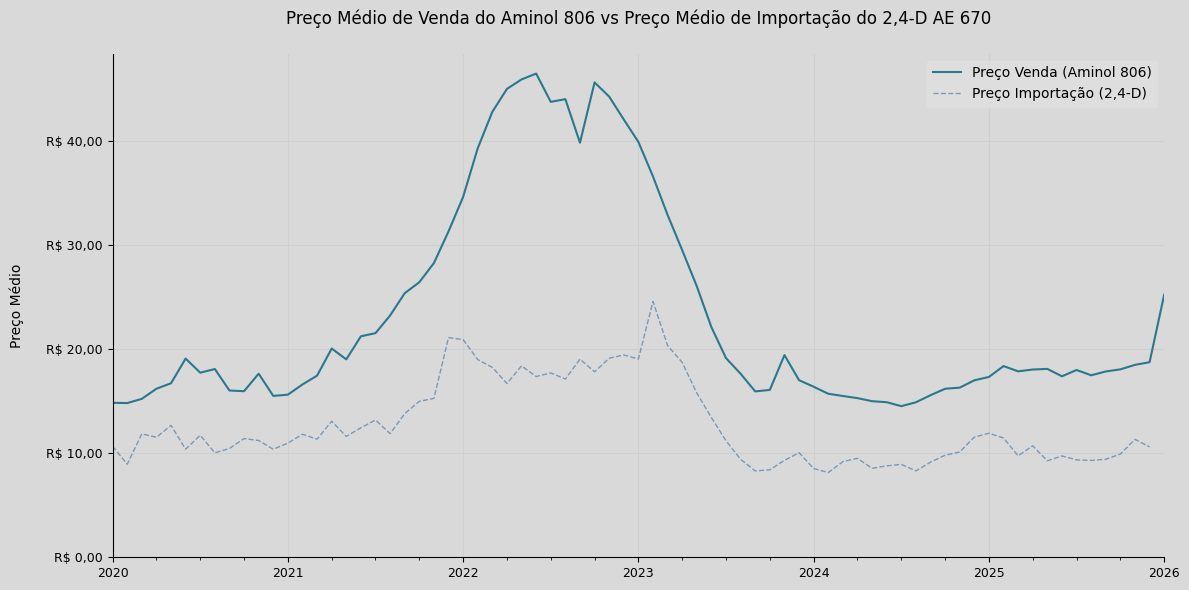

In [60]:
set_plot_style()

ax = preco_35.set_index('ano_mes')['preco_venda_brl'].plot(color = corViridis[2], label='Preço Venda (Aminol 806)')
preco_35.set_index('ano_mes')['preco_import_brl'].plot(ax = ax, color = corDefault, alpha = 0.8, linewidth = 1, linestyle = '--', label='Preço Importação (2,4-D)')
ax.set_title('Preço Médio de Venda do Aminol 806 vs Preço Médio de Importação do 2,4-D AE 670\n')
ax.grid(axis='both', color = '0.81')
ax.set_xlabel("")
ax.set_ylabel("Preço Médio\n")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')))
ax.tick_params(axis='both', labelsize=9)
ax.set_ylim(bottom = 0)
ax.legend(loc='upper right', facecolor='0.88', edgecolor='0.88')

plt.gcf().set_size_inches(12, 6)
plt.tight_layout()
plt.show()
plt.close()

O primeiro gráfico já mostra um aumento do preço de venda do `Aminol 806` de em torno de três vezes do que estava sendo negociado no começo da série temporal. Importante frisar que esse aumento é muito mais expressivo do que o aumento do custo de importação do ingrediente ativo `2,4-D AE 670`. O pico se mostra no segundo trimestre de 2022, após o início da guerra da Ucrânia em Fevereiro de 2022, mas vê-se que o aumento começou durante a pandemia (no segundo trimestre de 2021).

Em Abril de 2021 foi reportado pelo [AgroPages](https://news.agropages.com/News/NewsDetail---38942.htm) que a cadeia de produção de um dos herbicidas mais usados no Brasil estava desestabilizada devido ao aumento de preço, escassez de oferta e incerteza do mercado. Com o início da guerra da Ucrânia em Fevereiro de 2022, os preços atingiram patamares ainda mais elevados. O preço de venda do `Aminol 806` acompanhou essa escalada, saltando de aproximadamente 15 BRL para mais de 45 BRL no período. A partir do segundo semestre de 2022, a combinação de retração na demanda devido aos preços elevados, manutenção das exportações e normalização da cadeia de suprimentos permitiu uma queda gradual. Em 2023, [o glifosato registrou retração de 65% nos preços em 12 meses](https://www.theagribiz.com/agronegocio/lavoro-ve-mercado-de-insumos-de-volta-ao-normal-em-2024/).

Observa-se também uma aparente defasagem temporal entre as variações do preço de importação e o preço de venda ao distribuidor, sugerindo um repasse não imediato dos custos ao longo da cadeia, aspecto que será quantificado na análise de correlação.

In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
i The deprecated feature was likely used in the ggtime package.
  Please report the issue to the authors.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was generated. 


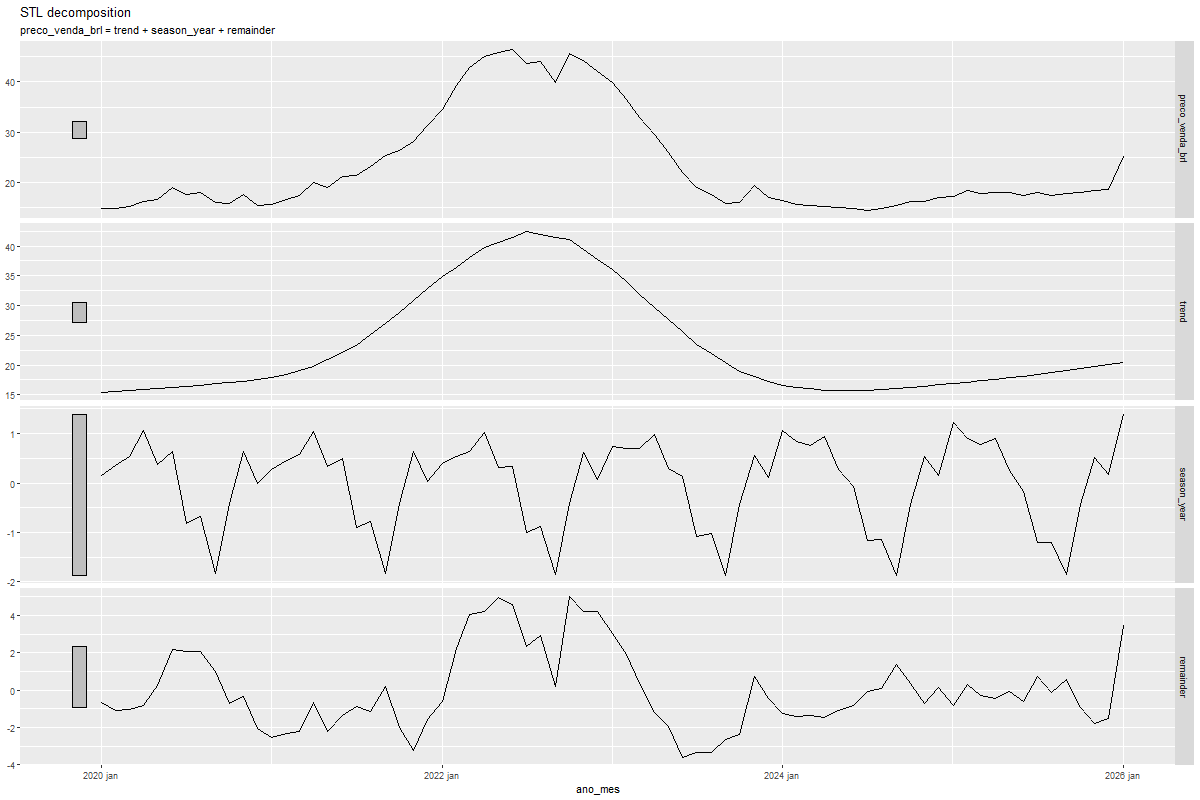

In [61]:
%%R -w 1200 -h 800 -u px
preco_35 |>
    model(stl = STL(preco_venda_brl)) -> dcmp_preco_35

components(dcmp_preco_35) |> autoplot()

A decomposição da série temporal do preço de venda do `Aminol 806` confirma os padrões observados no gráfico anterior.

A **tendência** mostra estabilidade em torno de 15-17 BRL até 2021, seguida de uma escalada até o pico de aproximadamente 42 BRL em meados de 2022, depois veio sofrendo queda gradual até 15 BRL em 2024 e uma retomada para cerca de 20 BRL no final de 2025. Estando, atualmente, em uma tendência de crescimento.

A **sazonalidade** apresenta amplitude pequena (oscilando entre -2 BRL e +1 BRL), indicando que variações sazonais explicam pouco da dinâmica de preços deste produto, diferentemente do que seria esperado em commodities com safras bem definidas. A sazonalidade tem picos em Março e Outubro, início de queda em Maio e atinge o seu vale em Agosto.

Os **resíduos** mostram valores elevados durante 2022, o que é esperado dado que choques externos como a guerra na Ucrânia são difíceis de capturar em modelos de decomposição. No final de 2025, observa-se um resíduo positivo que coincide com a alta recente no preço de importação. Esse movimento pode estar associado à [redução de capacidade produtiva por fabricantes chineses](https://revistacoopercitrus.com.br/mercado-de-defensivos-exige-planejamento-e-atencao-a-riscos-de-escassez/) devido a sua baixa rentabilidade. A Revista Coopercitrus cita 2,4-D, glifosato, glufosinato, flumioxazina e amicarbazona como as moléculas que podem ter maior impacto.

Só por esta primeira decomposição, já temos hipóteses de novas features que podem ajudar o modelo preditivo:
1. A tendência segue um padrão de polinômio cúbico que pode ser capturada introduzindo uma feature $t + t^2 + t^3$, splines, média móvel ou uma combinação;
2. A sazonalidade pode ter seu ciclo anual capturado com seno/cosseno;
3. Os padrões introduzidos pelos resíduos precisariam de variáveis externas para serem capturadas, como:
    - Variáveis desafadas do preço de importação;
    - Cotação do dólar;
    - Preço do petróleo;
    - Índice de frete marítimo como Baltic Dry Index (BDI) e Drewry World Container Index (WCI);
    - Área plantada na última safra das culturas que usam a molécula;
    - Preço das commodities agrícolas;
    - Índice de Confiança do Agronegócio (IC Agro);
    - Taxa Selic;
    - Precipitação;
    - Indicadores do El Niño/La Niña como o [Oceanic Niño Index (ONI)](https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php) e o [Southern Oscillation Index (SOI)](https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/ensocycle/soi.shtml);
    - Nível de estoque das revendas.

### **PRODUTO: U 46 BR (ID 376)**

In [62]:
preco_376 = precosdf[precosdf['IdProduto'] == 376].copy().reset_index(drop = True)
preco_376['ano_mes'] = pd.to_datetime(preco_376["ano_mes"] + "-01")

df_tsibble(preco_376, 'ano_mes', 'preco_376')

# A tsibble: 73 x 6 [1M]
    ano_mes IdProduto preco_venda_brl NomeMQEstat GrupoIA      preco_import_brl
      <mth>     <int>           <dbl> <chr>       <chr>                   <dbl>
 1 2020 jan       376            14.9 U 46 BR     2,4-D AE 670            10.7 
 2 2020 fev       376            15.0 U 46 BR     2,4-D AE 670             8.94
 3 2020 mar       376            14.7 U 46 BR     2,4-D AE 670            11.8 
 4 2020 abr       376            15.7 U 46 BR     2,4-D AE 670            11.5 
 5 2020 mai       376            16.3 U 46 BR     2,4-D AE 670            12.7 
 6 2020 jun       376            20.7 U 46 BR     2,4-D AE 670            10.4 
 7 2020 jul       376            17.1 U 46 BR     2,4-D AE 670            11.7 
 8 2020 ago       376            16.4 U 46 BR     2,4-D AE 670            10.0 
 9 2020 set       376            16.2 U 46 BR     2,4-D AE 670            10.4 
10 2020 out       376            16.9 U 46 BR     2,4-D AE 670            11.4 
# i 63 more row

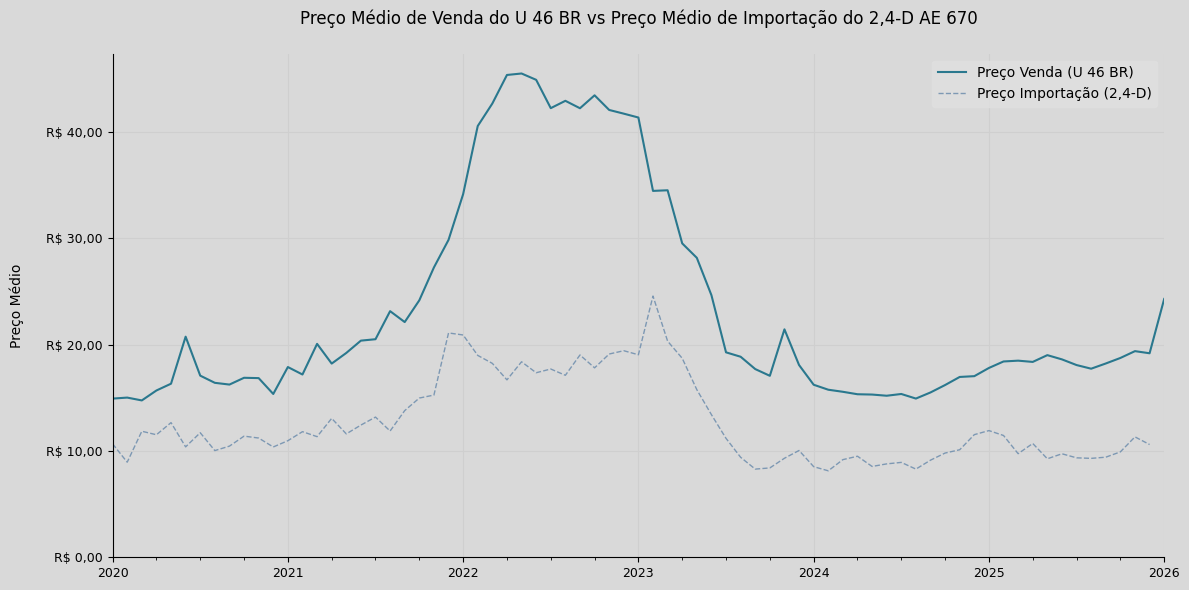

In [63]:
set_plot_style()

ax = preco_376.set_index('ano_mes')['preco_venda_brl'].plot(color = corViridis[2], label='Preço Venda (U 46 BR)')
preco_376.set_index('ano_mes')['preco_import_brl'].plot(ax = ax, color = corDefault, alpha = 0.8, linewidth = 1, linestyle = '--', label='Preço Importação (2,4-D)')
ax.set_title('Preço Médio de Venda do U 46 BR vs Preço Médio de Importação do 2,4-D AE 670\n')
ax.grid(axis='both', color = '0.81')
ax.set_xlabel("")
ax.set_ylabel("Preço Médio\n")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')))
ax.tick_params(axis='both', labelsize=9)
ax.set_ylim(bottom = 0)
ax.legend(loc='upper right', facecolor='0.88', edgecolor='0.88')

plt.gcf().set_size_inches(12, 6)
plt.tight_layout()
plt.show()
plt.close()

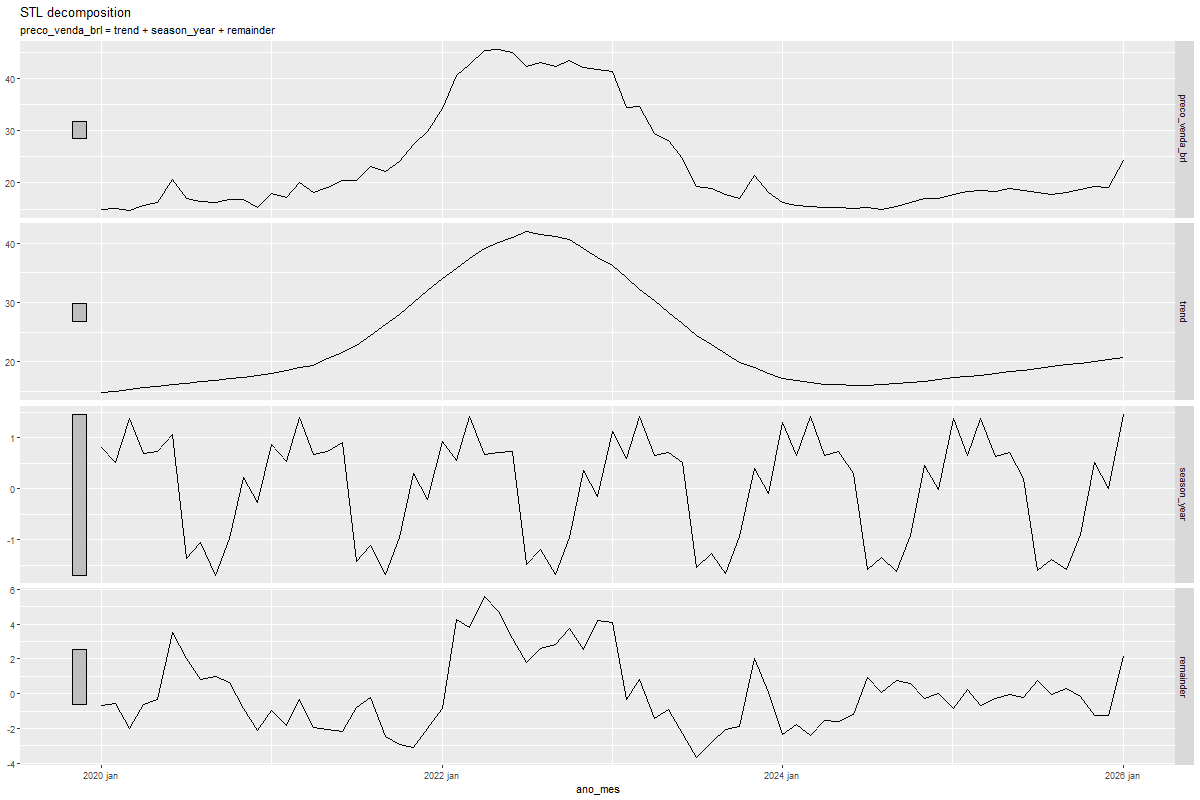

In [64]:
%%R -w 1200 -h 800 -u px
preco_376 |>
    model(stl = STL(preco_venda_brl)) -> dcmp_preco_376

components(dcmp_preco_376) |> autoplot()

Vemos que o `U 46 BR` possui padrão praticamente idêntico ao `Aminol 806`, mostrando que produtos com o mesmo ingrediente ativo (`2,4-D AE 670`) apresentam dinâmicas de preço altamente correlacionadas, sugerindo que o custo da matéria-prima é o principal driver e que diferenças entre produtos (marca, formulação, concentração) têm impacto secundário na variação temporal.

Isso sugere uma hipótese inicial de que em um modelo preditivo, pode fazer mais sentido modelar por grupo de ingrediente ativo ao invés de produto individual.

### **PRODUTO: 2,4-D NORTOX (ID 2741)**

In [65]:
preco_2741 = precosdf[precosdf['IdProduto'] == 2741].copy().reset_index(drop = True)
preco_2741['ano_mes'] = pd.to_datetime(preco_2741["ano_mes"] + "-01")

df_tsibble(preco_2741, 'ano_mes', 'preco_2741')

# A tsibble: 73 x 6 [1M]
    ano_mes IdProduto preco_venda_brl NomeMQEstat  GrupoIA      preco_import_brl
      <mth>     <int>           <dbl> <chr>        <chr>                   <dbl>
 1 2020 jan      2741            15.1 2 4-D Nortox 2,4-D AE 670            10.7 
 2 2020 fev      2741            15.2 2 4-D Nortox 2,4-D AE 670             8.94
 3 2020 mar      2741            15.5 2 4-D Nortox 2,4-D AE 670            11.8 
 4 2020 abr      2741            16.2 2 4-D Nortox 2,4-D AE 670            11.5 
 5 2020 mai      2741            16.8 2 4-D Nortox 2,4-D AE 670            12.7 
 6 2020 jun      2741            17.2 2 4-D Nortox 2,4-D AE 670            10.4 
 7 2020 jul      2741            17.1 2 4-D Nortox 2,4-D AE 670            11.7 
 8 2020 ago      2741            16.6 2 4-D Nortox 2,4-D AE 670            10.0 
 9 2020 set      2741            16.0 2 4-D Nortox 2,4-D AE 670            10.4 
10 2020 out      2741            15.7 2 4-D Nortox 2,4-D AE 670            11.4 
# i

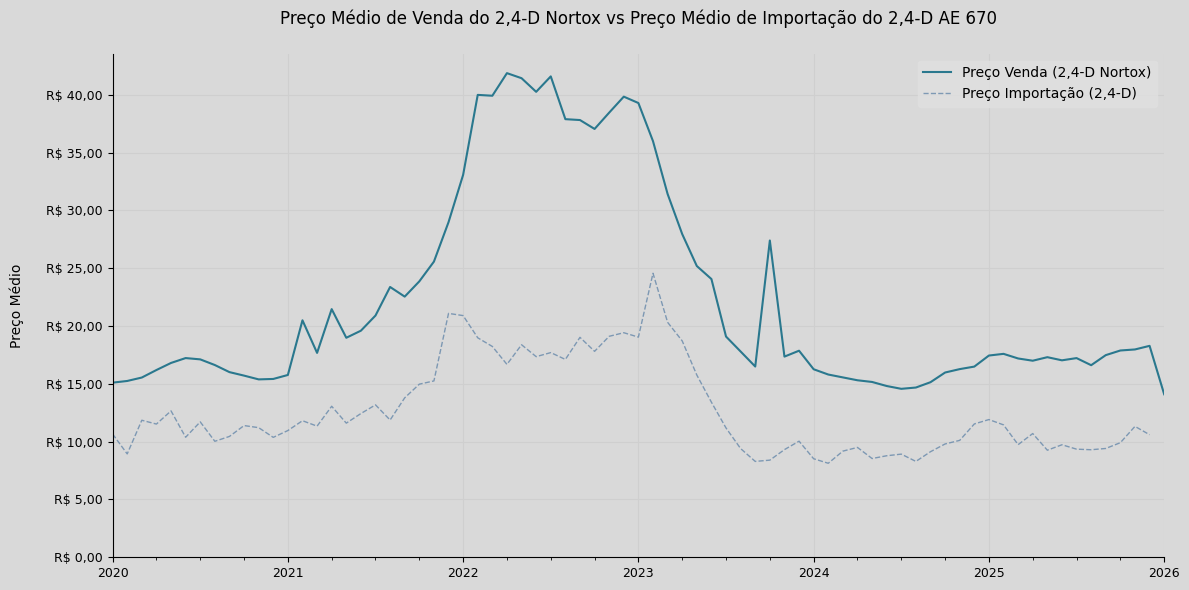

In [66]:
set_plot_style()

ax = preco_2741.set_index('ano_mes')['preco_venda_brl'].plot(color = corViridis[2], label='Preço Venda (2,4-D Nortox)')
preco_2741.set_index('ano_mes')['preco_import_brl'].plot(ax = ax, color = corDefault, alpha = 0.8, linewidth = 1, linestyle = '--', label='Preço Importação (2,4-D)')
ax.set_title('Preço Médio de Venda do 2,4-D Nortox vs Preço Médio de Importação do 2,4-D AE 670\n')
ax.grid(axis='both', color = '0.81')
ax.set_xlabel("")
ax.set_ylabel("Preço Médio\n")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')))
ax.tick_params(axis='both', labelsize=9)
ax.set_ylim(bottom = 0)
ax.legend(loc='upper right', facecolor='0.88', edgecolor='0.88')

plt.gcf().set_size_inches(12, 6)
plt.tight_layout()
plt.show()
plt.close()

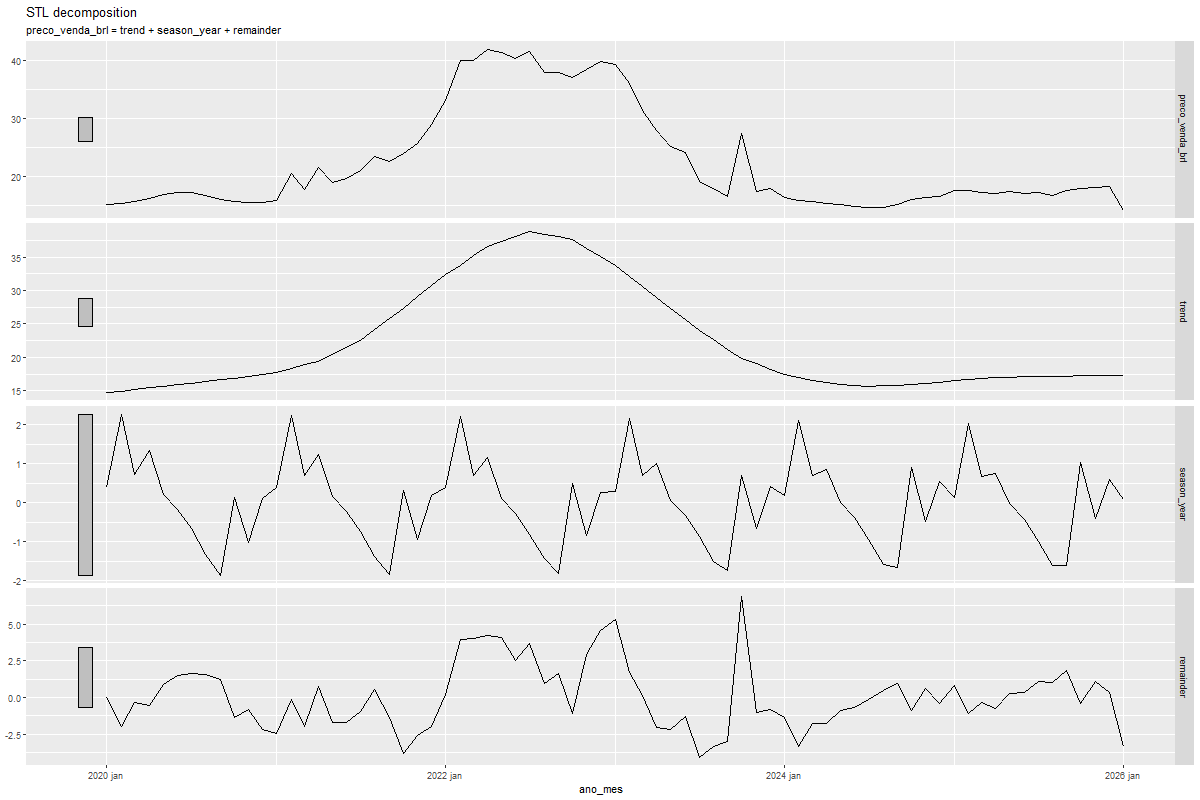

In [67]:
%%R -w 1200 -h 800 -u px
preco_2741 |>
    model(stl = STL(preco_venda_brl)) -> dcmp_preco_2741

components(dcmp_preco_2741) |> autoplot()

O `2,4-D Nortox` apresenta um comportamento distinto dos demais produtos do mesmo ingrediente ativo no final da série: enquanto `Aminol 806` e `U 46 BR` retomam trajetória de alta em 2025, o `2,4-D Nortox` mostra queda acentuada. Essa divergência pode ser explicada pelo posicionamento de mercado da Nortox. A Nortox é a maior fabricante nacional de agroquímicos, com estratégia focada em genéricos competitivos por preço, enquanto os outros dois produtos são de multinacionais com posicionamento premium.

### **PRODUTO: ROUNDUP WG (ID 475)**

In [68]:
preco_475 = precosdf[precosdf['IdProduto'] == 475].copy().reset_index(drop = True)
preco_475['ano_mes'] = pd.to_datetime(preco_475["ano_mes"] + "-01")

df_tsibble(preco_475, 'ano_mes', 'preco_475')

# A tsibble: 73 x 6 [1M]
    ano_mes IdProduto preco_venda_brl NomeMQEstat GrupoIA               preco_import_brl
      <mth>     <int>           <dbl> <chr>       <chr>                            <dbl>
 1 2020 jan       475            24.5 Roundup WG  GLYPHOSATE AE 500/720             14.9
 2 2020 fev       475            24.4 Roundup WG  GLYPHOSATE AE 500/720             13.4
 3 2020 mar       475            24.6 Roundup WG  GLYPHOSATE AE 500/720             14.8
 4 2020 abr       475            25.7 Roundup WG  GLYPHOSATE AE 500/720             17.9
 5 2020 mai       475            26.2 Roundup WG  GLYPHOSATE AE 500/720             17.8
 6 2020 jun       475            26.6 Roundup WG  GLYPHOSATE AE 500/720             16.1
 7 2020 jul       475            26.5 Roundup WG  GLYPHOSATE AE 500/720             16.2
 8 2020 ago       475            25.6 Roundup WG  GLYPHOSATE AE 500/720             17.6
 9 2020 set       475            24.9 Roundup WG  GLYPHOSATE AE 500/720             1

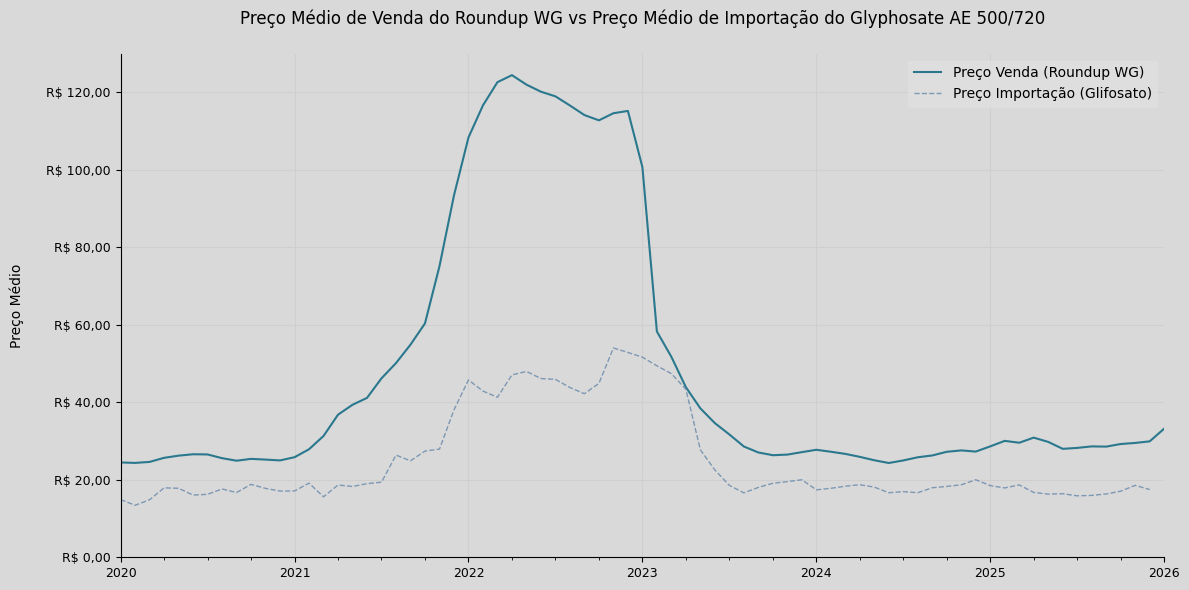

In [69]:
set_plot_style()

ax = preco_475.set_index('ano_mes')['preco_venda_brl'].plot(color = corViridis[2], label='Preço Venda (Roundup WG)')
preco_475.set_index('ano_mes')['preco_import_brl'].plot(ax = ax, color = corDefault, alpha = 0.8, linewidth = 1, linestyle = '--', label='Preço Importação (Glifosato)')
ax.set_title('Preço Médio de Venda do Roundup WG vs Preço Médio de Importação do Glyphosate AE 500/720\n')
ax.grid(axis='both', color = '0.81')
ax.set_xlabel("")
ax.set_ylabel("Preço Médio\n")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')))
ax.tick_params(axis='both', labelsize=9)
ax.set_ylim(bottom = 0)
ax.legend(loc='upper right', facecolor='0.88', edgecolor='0.88')

plt.gcf().set_size_inches(12, 6)
plt.tight_layout()
plt.show()
plt.close()

O `Roundup WG` apresenta uma amplitude de variação de preço significativamente maior que os produtos com ingrediente ativo `2,4-D AE 670` durante o período de crise (2021-2022). Enquanto os herbicidas à base de `2,4-D` triplicaram de valor (de 15 BRL para 45 BRL), o `Roundup WG` quintuplicou (de 25 BRL para 120 BRL). Essa diferença pode ser explicada por fatores estruturais do mercado de glifosato: [é o herbicida mais consumido no mundo](https://www.researchandmarkets.com/reports/4600335/research-report-on-chinas-glyphosate-industry), com [produção concentrada na China (66% da oferta global)](https://www.dgchemtech.com/2025-glyphosate-market-situation-and-technology-introduction.html), tornando-o mais vulnerável a choques de oferta.

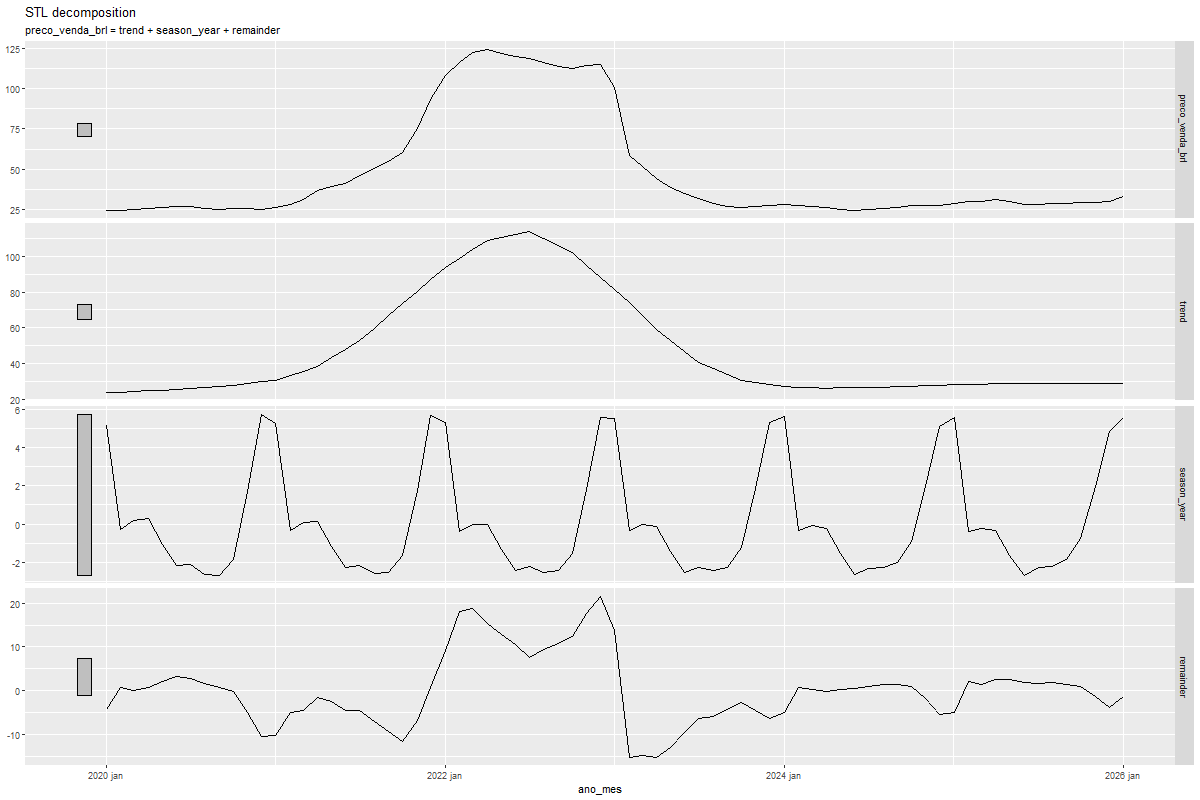

In [70]:
%%R -w 1200 -h 800 -u px
preco_475 |>
    model(stl = STL(preco_venda_brl)) -> dcmp_preco_475

components(dcmp_preco_475) |> autoplot()

A decomposição da série temporal do `Roundup WG` revela padrões distintos dos produtos com ingrediente ativo `2,4-D`.

A **tendência** captura bem o ciclo de crise, subindo de 25 BRL até 110 BRL no pico de 2022, retornando ao patamar base após a normalização.

A **sazonalidade** apresenta amplitude significativamente maior, variando de -2 a +6 BRL, contra -2 a +1 BRL do `2,4-D`. Os picos sazonais são pronunciados e regulares, ocorrendo no último trimestre de cada ano.

Os **resíduos** também são mais elevados, com amplitude de -15 a +20 BRL (contra -4 a +6 BRL do `2,4-D`), indicando que a tendência e sazonalidade não conseguiram capturar toda a magnitude dos choques externos.

### **PRODUTO: ZAPP QI 620 (ID 2560)**

In [71]:
preco_2560 = precosdf[precosdf['IdProduto'] == 2560].copy().reset_index(drop = True)
preco_2560['ano_mes'] = pd.to_datetime(preco_2560["ano_mes"] + "-01")

df_tsibble(preco_2560, 'ano_mes', 'preco_2560')

# A tsibble: 73 x 6 [1M]
    ano_mes IdProduto preco_venda_brl NomeMQEstat GrupoIA               preco_import_brl
      <mth>     <int>           <dbl> <chr>       <chr>                            <dbl>
 1 2020 jan      2560            16.9 Zapp QI 620 GLYPHOSATE AE 500/720             14.9
 2 2020 fev      2560            16.3 Zapp QI 620 GLYPHOSATE AE 500/720             13.4
 3 2020 mar      2560            16.4 Zapp QI 620 GLYPHOSATE AE 500/720             14.8
 4 2020 abr      2560            17.2 Zapp QI 620 GLYPHOSATE AE 500/720             17.9
 5 2020 mai      2560            18.0 Zapp QI 620 GLYPHOSATE AE 500/720             17.8
 6 2020 jun      2560            19.6 Zapp QI 620 GLYPHOSATE AE 500/720             16.1
 7 2020 jul      2560            18.9 Zapp QI 620 GLYPHOSATE AE 500/720             16.2
 8 2020 ago      2560            18.5 Zapp QI 620 GLYPHOSATE AE 500/720             17.6
 9 2020 set      2560            17.7 Zapp QI 620 GLYPHOSATE AE 500/720             1

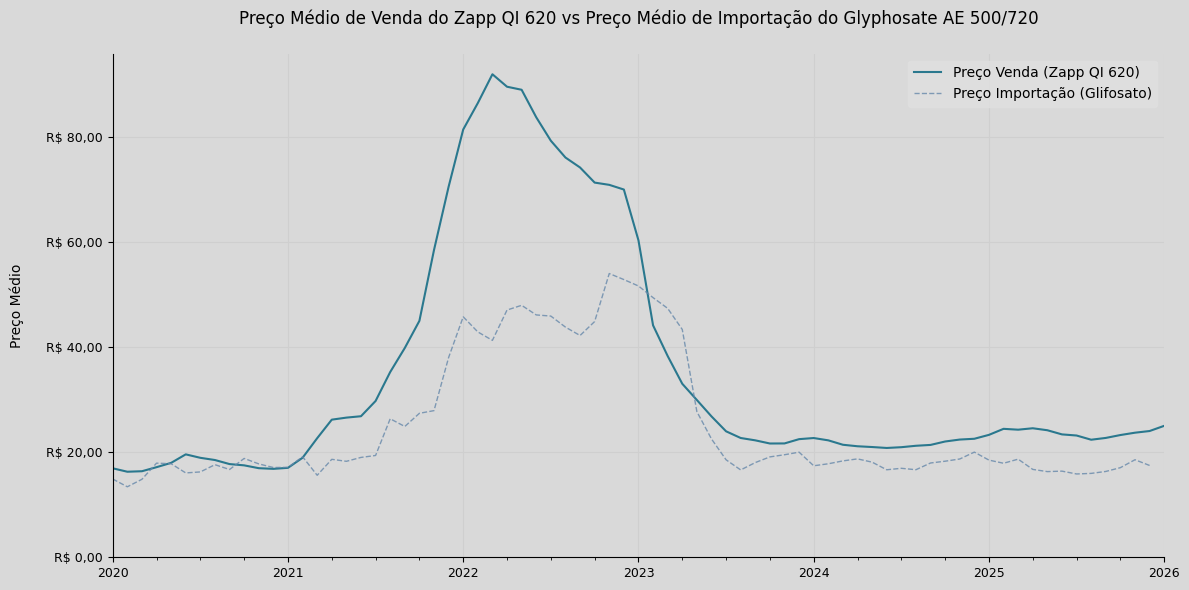

In [72]:
set_plot_style()

ax = preco_2560.set_index('ano_mes')['preco_venda_brl'].plot(color = corViridis[2], label='Preço Venda (Zapp QI 620)')
preco_2560.set_index('ano_mes')['preco_import_brl'].plot(ax = ax, color = corDefault, alpha = 0.8, linewidth = 1, linestyle = '--', label='Preço Importação (Glifosato)')
ax.set_title('Preço Médio de Venda do Zapp QI 620 vs Preço Médio de Importação do Glyphosate AE 500/720\n')
ax.grid(axis='both', color = '0.81')
ax.set_xlabel("")
ax.set_ylabel("Preço Médio\n")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')))
ax.tick_params(axis='both', labelsize=9)
ax.set_ylim(bottom = 0)
ax.legend(loc='upper right', facecolor='0.88', edgecolor='0.88')

plt.gcf().set_size_inches(12, 6)
plt.tight_layout()
plt.show()
plt.close()

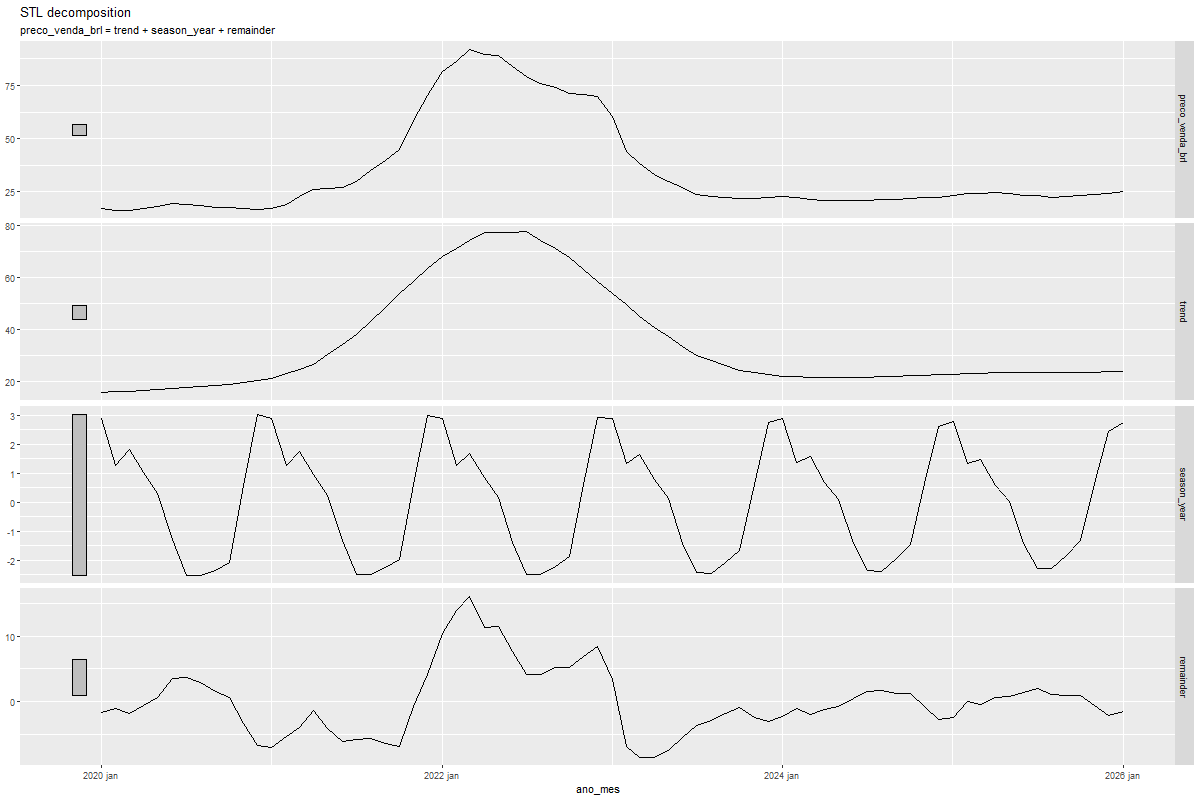

In [73]:
%%R -w 1200 -h 800 -u px
preco_2560 |>
    model(stl = STL(preco_venda_brl)) -> dcmp_preco_2560

components(dcmp_preco_2560) |> autoplot()

O `Zapp QI 620` apresenta dinâmica similar ao `Roundup WG`, porém com amplitudes consistentemente menores. Enquanto o `Roundup WG` atingiu pico de 120 BRL em 2022, o `Zapp QI 620` alcançou 90 BRL. A decomposição confirma esse padrão, mostrando que a sazonalidade do `Zapp QI 620` tem amplitude de 5 BRL (contra 8 BRL do `Roundup WG`) e os resíduos variam de -5 a +15 BRL (contra -15 a +20 BRL).

Isso sugere que o `Roundup WG`, produzido pela Bayer (ex-Monsanto), sendo a marca original do glifosato e mais reconhecida no mercado, consegue capturar margens superiores em períodos de escassez pela força da marca.

Na modelagem preditiva, isso pode ser traduzido para o modelo em forma de features que mostram a força de marca ou posicionamento de mercado.

### **PRODUTO: GLYPHOSATE AE 720 POST-PATENT (ID 4554)**

In [74]:
preco_4554 = precosdf[precosdf['IdProduto'] == 4554].copy().reset_index(drop = True)
preco_4554['ano_mes'] = pd.to_datetime(preco_4554["ano_mes"] + "-01")

df_tsibble(preco_4554, 'ano_mes', 'preco_4554')

# A tsibble: 43 x 6 [1M]
    ano_mes IdProduto preco_venda_brl NomeMQEstat                   GrupoIA               preco_import_brl
      <mth>     <int>           <dbl> <chr>                         <chr>                            <dbl>
 1 2020 jul      4554            25.8 Glyphosate AE 720 Post-Patent GLYPHOSATE AE 500/720             16.2
 2 2020 ago      4554            26.0 Glyphosate AE 720 Post-Patent GLYPHOSATE AE 500/720             17.6
 3 2020 set      4554            25.7 Glyphosate AE 720 Post-Patent GLYPHOSATE AE 500/720             16.7
 4 2020 out      4554            25.2 Glyphosate AE 720 Post-Patent GLYPHOSATE AE 500/720             18.8
 5 2020 nov      4554            25.3 Glyphosate AE 720 Post-Patent GLYPHOSATE AE 500/720             17.8
 6 2020 dez      4554            26.9 Glyphosate AE 720 Post-Patent GLYPHOSATE AE 500/720             17.1
 7 2021 jan      4554            25.0 Glyphosate AE 720 Post-Patent GLYPHOSATE AE 500/720             17.1
 8 2021 fev 

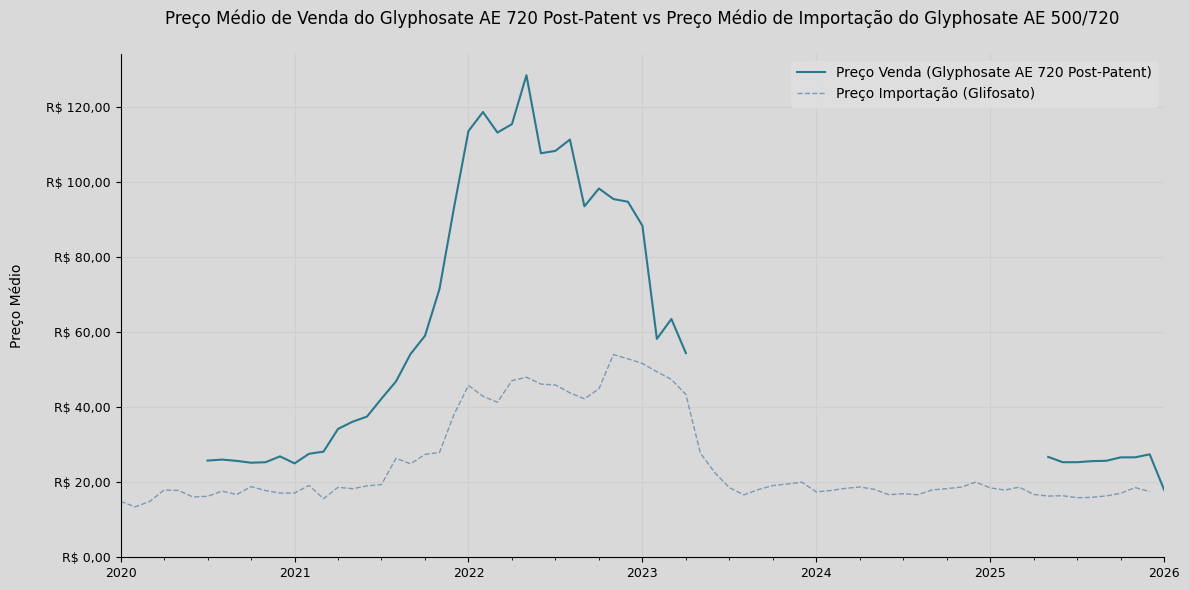

In [75]:
set_plot_style()

min_date = preco_4554['ano_mes'].min()
calendario_completo = pd.date_range(
    start = min_date,
    end = preco_4554['ano_mes'].max(),
    freq = 'MS'
)
preco_4554 = preco_4554.set_index('ano_mes').reindex(calendario_completo)

ax = preco_4554['preco_venda_brl'].plot(color = corViridis[2], label='Preço Venda (Glyphosate AE 720 Post-Patent)')
preco_2560.set_index('ano_mes')['preco_import_brl'].plot(ax = ax, color = corDefault, alpha = 0.8, linewidth = 1, linestyle = '--', label='Preço Importação (Glifosato)')
ax.set_title('Preço Médio de Venda do Glyphosate AE 720 Post-Patent vs Preço Médio de Importação do Glyphosate AE 500/720\n')
ax.grid(axis='both', color = '0.81')
ax.set_xlabel("")
ax.set_ylabel("Preço Médio\n")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')))
ax.tick_params(axis='both', labelsize=9)
ax.set_ylim(bottom = 0)
ax.legend(loc='upper right', facecolor='0.88', edgecolor='0.88')

plt.gcf().set_size_inches(12, 6)
plt.tight_layout()
plt.show()
plt.close()

O `Glyphosate AE 720 Post-Patent` apresenta um gap de 24 meses na série (maio/2023 a abril/2025), impossibilitando a decomposição completa da série temporal. O produto provavelmente agrega múltiplas marcas.

Antes do gap, o produto apresentou comportamento similar aos demais produtos de glifosato, com pico de 130 BRL em 2022.
<br>A ausência de dados pode estar relacionada a mudanças na categorização do produto na pesquisa ou à indisponibilidade do produto nos distribuidores consultados durante o período.

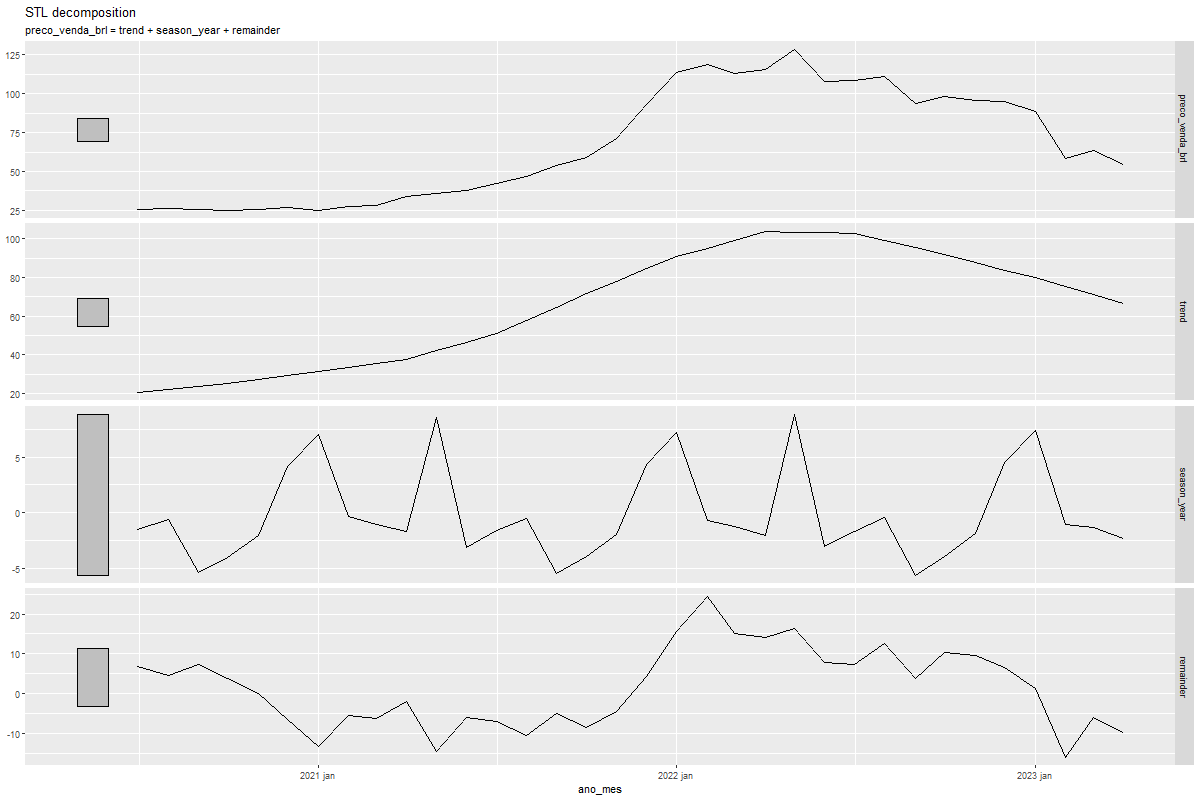

In [76]:
%%R -w 1200 -h 800 -u px
preco_4554 |>
    filter(year(ano_mes) <= 2023) -> preco_4554

preco_4554 |>
    model(stl = STL(preco_venda_brl)) -> dcmp_preco_4554

components(dcmp_preco_4554) |> autoplot()

A tendência do `Glyphosate AE 720 Post-Patent` segue o padrão dos demais produtos de glifosato, subindo de 20 BRL para 105 BRL no pico de 2022, confirmando que o ingrediente ativo é o principal driver de preço. Porém, a sazonalidade e os resíduos apresentam comportamento distinto. A amplitude sazonal é a maior entre os três produtos de glifosato analisados: aproximadamente 12 BRL (-5 a +7), contra 8 BRL do `Roundup WG` e 5 BRL do `Zapp QI 620`. Isso é consistente com o fato de ser um aglomerado de marcas: a variação reflete não apenas a sazonalidade do mercado, mas também as diferentes estratégias de precificação das marcas que compõem a categoria. Os resíduos elevados (-15 a +20 BRL) reforçam essa interpretação, capturando a heterogeneidade entre as marcas agregadas.

### **PRODUTO: MANZATE 750 WG (ID 1319)**

In [77]:
preco_1319 = precosdf[precosdf['IdProduto'] == 1319].copy().reset_index(drop = True)
preco_1319['ano_mes'] = pd.to_datetime(preco_1319["ano_mes"] + "-01")

df_tsibble(preco_1319, 'ano_mes', 'preco_1319')

# A tsibble: 72 x 6 [1M]
    ano_mes IdProduto preco_venda_brl NomeMQEstat    GrupoIA      preco_import_brl
      <mth>     <int>           <dbl> <chr>          <chr>                   <dbl>
 1 2020 jan      1319            21.6 Manzate 750 WG MANCOZEB 750             15.1
 2 2020 fev      1319            22.0 Manzate 750 WG MANCOZEB 750             15.8
 3 2020 mar      1319            21.1 Manzate 750 WG MANCOZEB 750             19.0
 4 2020 abr      1319            21.2 Manzate 750 WG MANCOZEB 750             19.2
 5 2020 mai      1319            24.4 Manzate 750 WG MANCOZEB 750             16.1
 6 2020 jun      1319            23.6 Manzate 750 WG MANCOZEB 750             15.0
 7 2020 jul      1319            24.0 Manzate 750 WG MANCOZEB 750             16.6
 8 2020 ago      1319            24.7 Manzate 750 WG MANCOZEB 750             18.4
 9 2020 set      1319            23.7 Manzate 750 WG MANCOZEB 750             20.1
10 2020 out      1319            24.8 Manzate 750 WG MANCOZEB 

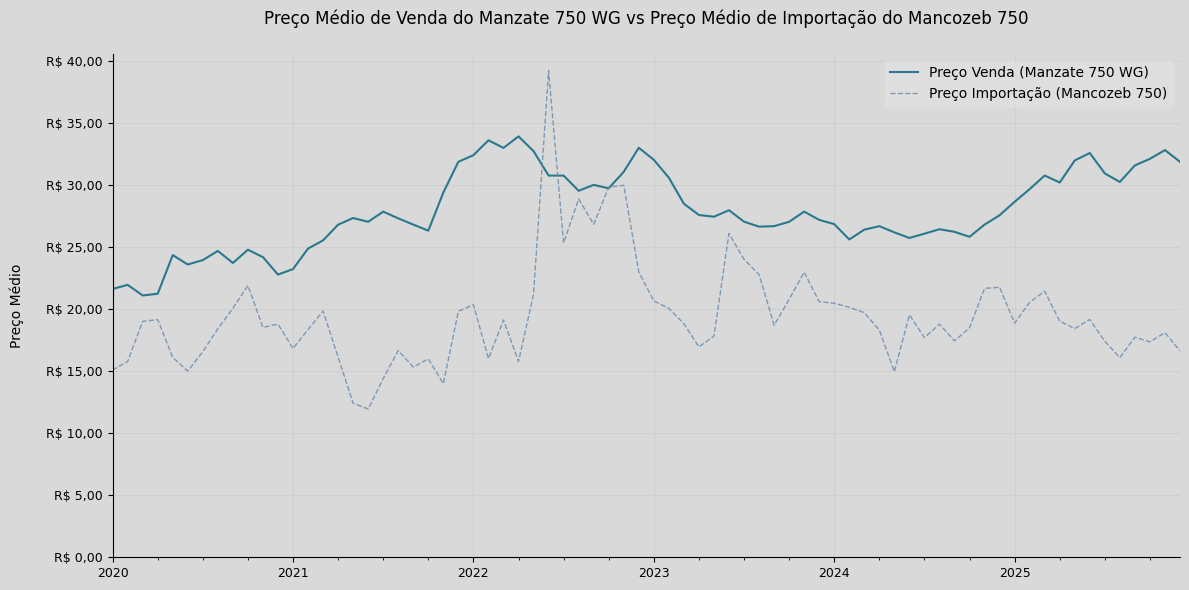

In [78]:
set_plot_style()

ax = preco_1319.set_index('ano_mes')['preco_venda_brl'].plot(color = corViridis[2], label='Preço Venda (Manzate 750 WG)')
preco_1319.set_index('ano_mes')['preco_import_brl'].plot(ax = ax, color = corDefault, alpha = 0.8, linewidth = 1, linestyle = '--', label='Preço Importação (Mancozeb 750)')
ax.set_title('Preço Médio de Venda do Manzate 750 WG vs Preço Médio de Importação do Mancozeb 750\n')
ax.grid(axis='both', color = '0.81')
ax.set_xlabel("")
ax.set_ylabel("Preço Médio\n")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')))
ax.tick_params(axis='both', labelsize=9)
ax.set_ylim(bottom = 0)
ax.legend(loc='upper right', facecolor='0.88', edgecolor='0.88')

plt.gcf().set_size_inches(12, 6)
plt.tight_layout()
plt.show()
plt.close()

O gráfico revela uma dinâmica de precificação distinta das observadas em herbicidas com Glifosato e 2,4-D. Enquanto o preço de importação do Mancozebe apresenta alta volatilidade, o preço de venda do `Manzate 750 WG` mantém-se notavelmente estável, mesmo com preço de importação atingindo o pico de 39 BRL devido aos efeitos da guerra na Ucrânia sobre custos de produção e logística.

A capacidade da UPL de absorver essa volatilidade decorre de sua posição como [líder global em Mancozebe](https://www.prnewswire.com/news-releases/upl-to-strengthen-fungicide-portfolio-with-planned-acquisition-of-cortevas-mancozeb-business-302028697.html) com [integração vertical às fábricas na Índia](https://www.upl-ltd.com/financial_result_and_report_pdfs/Ja7cpGoy1zA23RLCkvasNd2niUUeq0bzZ170P5BZ/US-Roadshow-Deck.pdf) (principal origem das importações brasileiras, respondendo por 62% do volume).

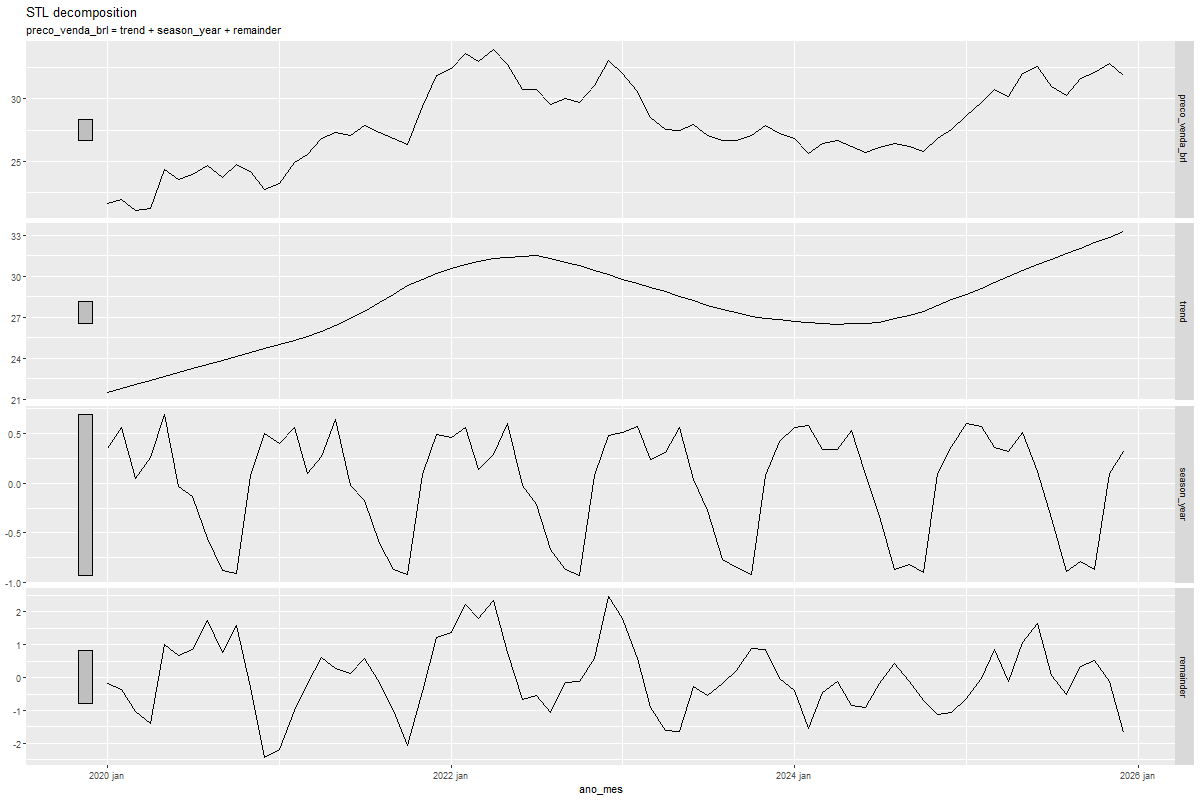

In [79]:
%%R -w 1200 -h 800 -u px
preco_1319 |>
    model(stl = STL(preco_venda_brl)) -> dcmp_preco_1319

components(dcmp_preco_1319) |> autoplot()

A decomposição da série temporal do `Manzate 750 WG` confirma a dinâmica diferente do produto.

A **tendência** é notavelmente suave e sem o pico dramático de 2022 que vimos no `2,4-D` e `Glifosato`. Isso confirma quantitativamente a estratégia da UPL de absorver os choques de custo gradualmente ao invés de repassá-los imediatamente.

A **sazonalidade** possui uma amplitude muito pequena, de -1.0 a +0.5 BRL. A demanda é sazonal, mas o preço de venda não reflete isso. Novamente, evidência de política de preços estáveis.

Os **resíduos** também são bem comportados, entre -2 e +2 BRL. Sem outliers extremos. A tendência e sazonalidade capturam bem a dinâmica da série.

### **PRODUTO: UNIZEB GOLD (ID 3026)**

In [80]:
preco_3026 = precosdf[precosdf['IdProduto'] == 3026].copy().reset_index(drop = True)
preco_3026['ano_mes'] = pd.to_datetime(preco_3026["ano_mes"] + "-01")

df_tsibble(preco_3026, 'ano_mes', 'preco_3026')

# A tsibble: 73 x 6 [1M]
    ano_mes IdProduto preco_venda_brl NomeMQEstat GrupoIA      preco_import_brl
      <mth>     <int>           <dbl> <chr>       <chr>                   <dbl>
 1 2020 jan      3026            20.6 Unizeb Gold MANCOZEB 750             15.1
 2 2020 fev      3026            20.1 Unizeb Gold MANCOZEB 750             15.8
 3 2020 mar      3026            20.2 Unizeb Gold MANCOZEB 750             19.0
 4 2020 abr      3026            20.9 Unizeb Gold MANCOZEB 750             19.2
 5 2020 mai      3026            21.6 Unizeb Gold MANCOZEB 750             16.1
 6 2020 jun      3026            22.4 Unizeb Gold MANCOZEB 750             15.0
 7 2020 jul      3026            21.8 Unizeb Gold MANCOZEB 750             16.6
 8 2020 ago      3026            21.1 Unizeb Gold MANCOZEB 750             18.4
 9 2020 set      3026            19.8 Unizeb Gold MANCOZEB 750             20.1
10 2020 out      3026            19.3 Unizeb Gold MANCOZEB 750             21.9
# i 63 more row

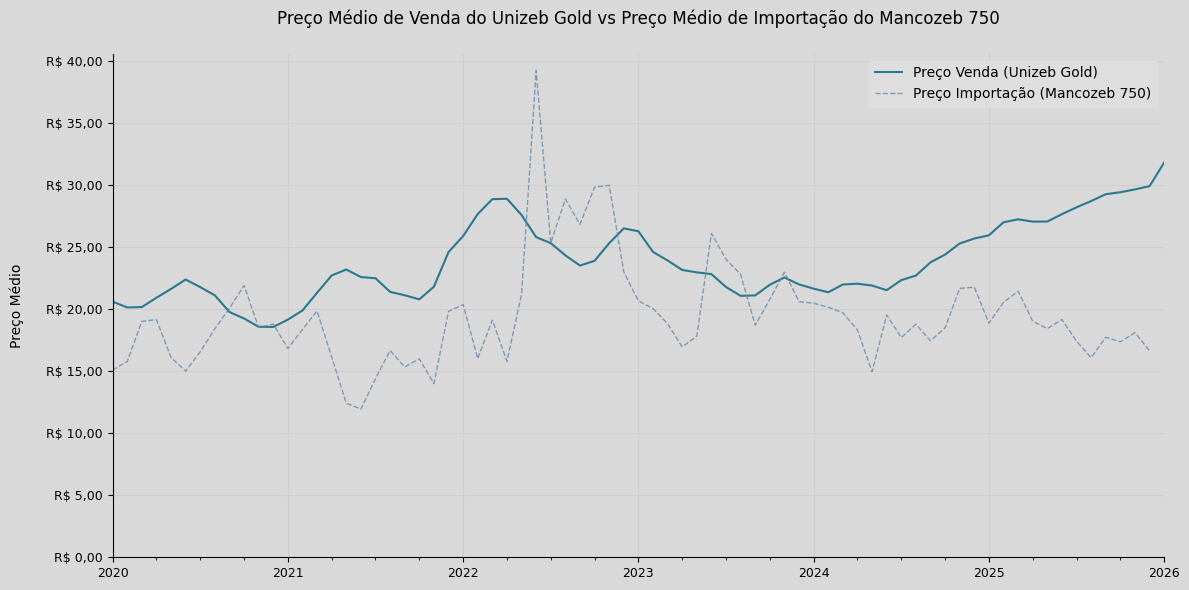

In [81]:
set_plot_style()

ax = preco_3026.set_index('ano_mes')['preco_venda_brl'].plot(color = corViridis[2], label='Preço Venda (Unizeb Gold)')
preco_3026.set_index('ano_mes')['preco_import_brl'].plot(ax = ax, color = corDefault, alpha = 0.8, linewidth = 1, linestyle = '--', label='Preço Importação (Mancozeb 750)')
ax.set_title('Preço Médio de Venda do Unizeb Gold vs Preço Médio de Importação do Mancozeb 750\n')
ax.grid(axis='both', color = '0.81')
ax.set_xlabel("")
ax.set_ylabel("Preço Médio\n")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')))
ax.tick_params(axis='both', labelsize=9)
ax.set_ylim(bottom = 0)
ax.legend(loc='upper right', facecolor='0.88', edgecolor='0.88')

plt.gcf().set_size_inches(12, 6)
plt.tight_layout()
plt.show()
plt.close()

O gráfico aprenta um comportamento visualmente distinto do `Manzate 750 WG`: enquanto o `Manzate 750 WG` mantém distância consistente do preço de importação, o `Unizeb Gold` opera com as duas linhas muito mais próximas. Como o `Manzate 750 WG` também pertence a UPL, isso indica uma estratégia deliberada de segmentação de mercado com o mesmo ingrediente ativo.

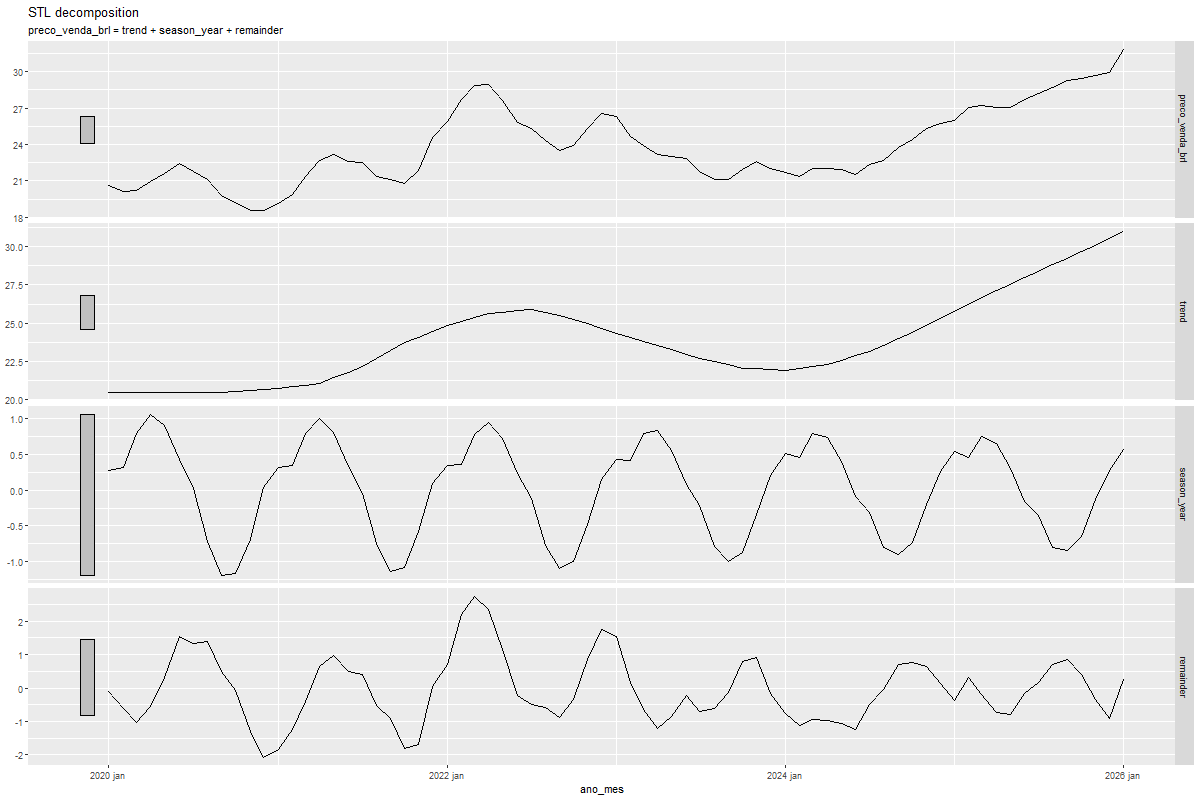

In [82]:
%%R -w 1200 -h 800 -u px
preco_3026 |>
    model(stl = STL(preco_venda_brl)) -> dcmp_preco_3026

components(dcmp_preco_3026) |> autoplot()

A decomposição da série temporal do `Unizeb Gold` confirma as dinâmicas de preço distinta para produtos com o mesmo ingrediente ativo mas que possuem mercado-alvo diferentes.

A **tendência** mostra um movimento de alta desde o começo de 2024, com um aumento visível mas suave em 2022. Como opera com margem menor, não tinha "gordura" para absorver o choque como o `Manzate 750 WG`.

A **sazonalidade** mostra um padrão diferente, confirmando o foco em uma cultura diferente.

Os **resíduos** são controlados, mostrando que a tendência e sazonalidade capturam bem a dinâmica de preços.

A comparação das duas decomposições ilustra como produtos com o mesmo ingrediente ativo podem ter dinâmicas de preço distintas dependendo do mercado-alvo.
<br>Isso mostra a necessidade de variáveis categóricas no modelo que capturem não só o ingrediente ativo, mas também o segmento de mercado (grandes culturas vs hortifrutigranjeiros).

### **PRODUTO: POQUER (ID 2734)**

In [83]:
preco_2734 = precosdf[precosdf['IdProduto'] == 2734].copy().reset_index(drop = True)
preco_2734['ano_mes'] = pd.to_datetime(preco_2734["ano_mes"] + "-01")

df_tsibble(preco_2734, 'ano_mes', 'preco_2734')

# A tsibble: 73 x 6 [1M]
    ano_mes IdProduto preco_venda_brl NomeMQEstat GrupoIA       preco_import_brl
      <mth>     <int>           <dbl> <chr>       <chr>                    <dbl>
 1 2020 jan      2734            56.8 Poquer      CLETHODIM 240             47.0
 2 2020 fev      2734            57.1 Poquer      CLETHODIM 240             56.3
 3 2020 mar      2734            56.9 Poquer      CLETHODIM 240             58.5
 4 2020 abr      2734            52.8 Poquer      CLETHODIM 240             77.1
 5 2020 mai      2734            52.2 Poquer      CLETHODIM 240             82.2
 6 2020 jun      2734            51.4 Poquer      CLETHODIM 240             72.4
 7 2020 jul      2734            52.3 Poquer      CLETHODIM 240             71.1
 8 2020 ago      2734            50.2 Poquer      CLETHODIM 240             62.4
 9 2020 set      2734            48.7 Poquer      CLETHODIM 240             54.6
10 2020 out      2734            48.7 Poquer      CLETHODIM 240             45.9
# i

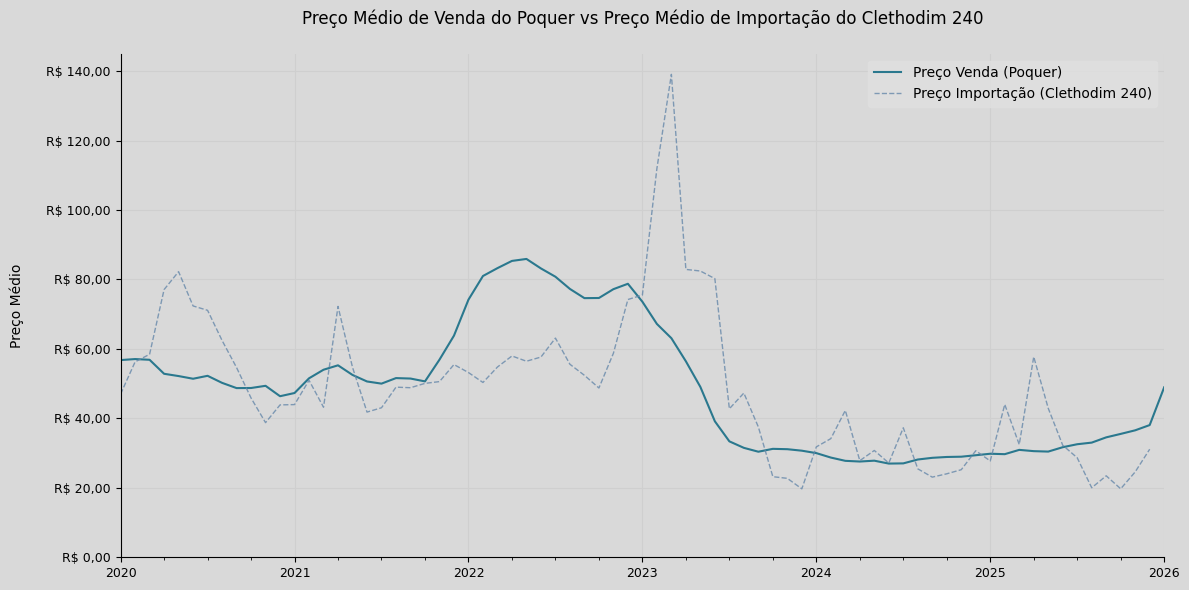

In [84]:
set_plot_style()

ax = preco_2734.set_index('ano_mes')['preco_venda_brl'].plot(color = corViridis[2], label='Preço Venda (Poquer)')
preco_2734.set_index('ano_mes')['preco_import_brl'].plot(ax = ax, color = corDefault, alpha = 0.8, linewidth = 1, linestyle = '--', label='Preço Importação (Clethodim 240)')
ax.set_title('Preço Médio de Venda do Poquer vs Preço Médio de Importação do Clethodim 240\n')
ax.grid(axis='both', color = '0.81')
ax.set_xlabel("")
ax.set_ylabel("Preço Médio\n")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')))
ax.tick_params(axis='both', labelsize=9)
ax.set_ylim(bottom = 0)
ax.legend(loc='upper right', facecolor='0.88', edgecolor='0.88')

plt.gcf().set_size_inches(12, 6)
plt.tight_layout()
plt.show()
plt.close()

O `Poquer` apresenta três fases distintas de preço:
1. Estabilidade em torno de 50 BRL entre 2020 e meados de 2021;
2. Uma escalada até o pico de aproximadamente 86 BRL em Maio de 2022, influenciada pela [escassez de Etil Mercaptano](https://news.agropages.com/News/NewsDetail---47617.htm), matéria-prima essencial para produção de Clethodim, cujo fornecimento é controlado por poucos fabricantes ocidentais;
3. Queda acentuada para cerca de 30 BRL a partir de meados de 2023, uma redução de aproximadamente 65%. Isso aconteceu, por conta dos [estoque elevados](https://agroreceita.com.br/preco-dos-defensivos-agricolas/) e pela China [passar a retomar gradativamente a sua produção interna de ativos após o relaxamento das políticas rigorosas de controle da Covid-19 em Dezembro de 2022](https://www.agrolink.com.br/noticias/como-vem-o-preco-dos-pesticidas--confira_478111.html). Desde então, o preço tem mostrado leve tendência de recuperação.

Vale ressaltar que a série de preço de importação apresentada no gráfico deve ser interpretada com cautela, pois os códigos NCM utilizados (38.08.93.29 e 29.30.90.39) agregam múltiplas moléculas além do Clethodim, impossibilitando isolar com precisão o custo real do ingrediente ativo.

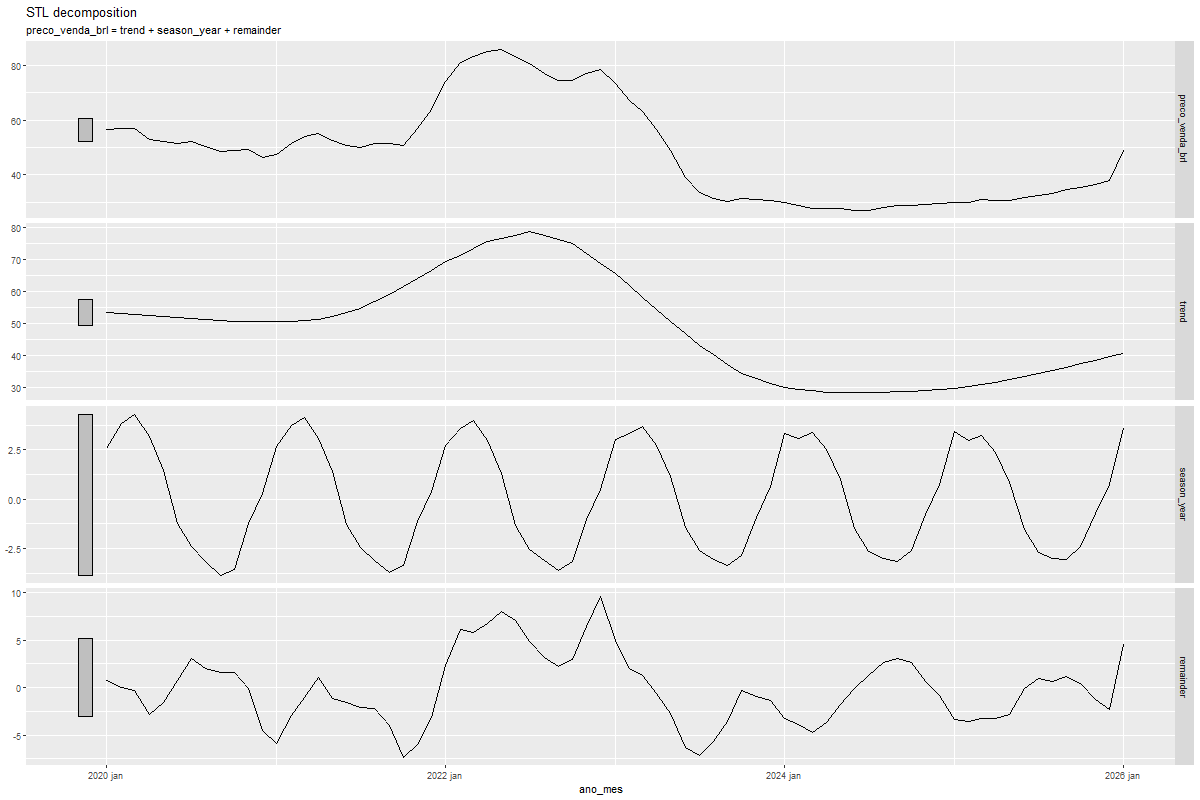

In [85]:
%%R -w 1200 -h 800 -u px
preco_2734 |>
    model(stl = STL(preco_venda_brl)) -> dcmp_preco_2734

components(dcmp_preco_2734) |> autoplot()

Com a decomposição da série temporal do `Poquer` vemos que:

A **tendência** confirma as três fases apontadas anteriormente. E, segundo a [Zhengzhou Delong Chemical Co.](https://www.plantgrowthhormones.com/news/herbicide-market-monitoring-march31-84969406.html), a tendência de crescimento que vemos em 2025 é devido a escassez de oferta.

A **sazonalidade** mostra um padrão regular durante o ano, com pico Fevereiro e vale em Agosto. Com uma amplitude moderada, indo de -2,5 a +2,5 BRL.

Os **resíduos** são relativamente bem comportados (entre -5 e +5 BRL) com maiores variações durante 2022.

### **PRODUTO: CLETHODIM 240 POST-PATENT (ID 4440)**

In [86]:
preco_4440 = precosdf[precosdf['IdProduto'] == 4440].copy().reset_index(drop = True)
preco_4440['ano_mes'] = pd.to_datetime(preco_4440["ano_mes"] + "-01")

df_tsibble(preco_4440, 'ano_mes', 'preco_4440')

# A tsibble: 42 x 6 [1M]
    ano_mes IdProduto preco_venda_brl NomeMQEstat               GrupoIA       preco_import_brl
      <mth>     <int>           <dbl> <chr>                     <chr>                    <dbl>
 1 2020 fev      4440            48.9 Clethodim 240 Post-Patent CLETHODIM 240             56.3
 2 2020 mai      4440            52.3 Clethodim 240 Post-Patent CLETHODIM 240             82.2
 3 2020 jul      4440            50.5 Clethodim 240 Post-Patent CLETHODIM 240             71.1
 4 2020 ago      4440            49.9 Clethodim 240 Post-Patent CLETHODIM 240             62.4
 5 2020 set      4440            48.2 Clethodim 240 Post-Patent CLETHODIM 240             54.6
 6 2020 out      4440            48.9 Clethodim 240 Post-Patent CLETHODIM 240             45.9
 7 2020 nov      4440            50.1 Clethodim 240 Post-Patent CLETHODIM 240             38.8
 8 2020 dez      4440            51.1 Clethodim 240 Post-Patent CLETHODIM 240             43.9
 9 2021 jan      4440    

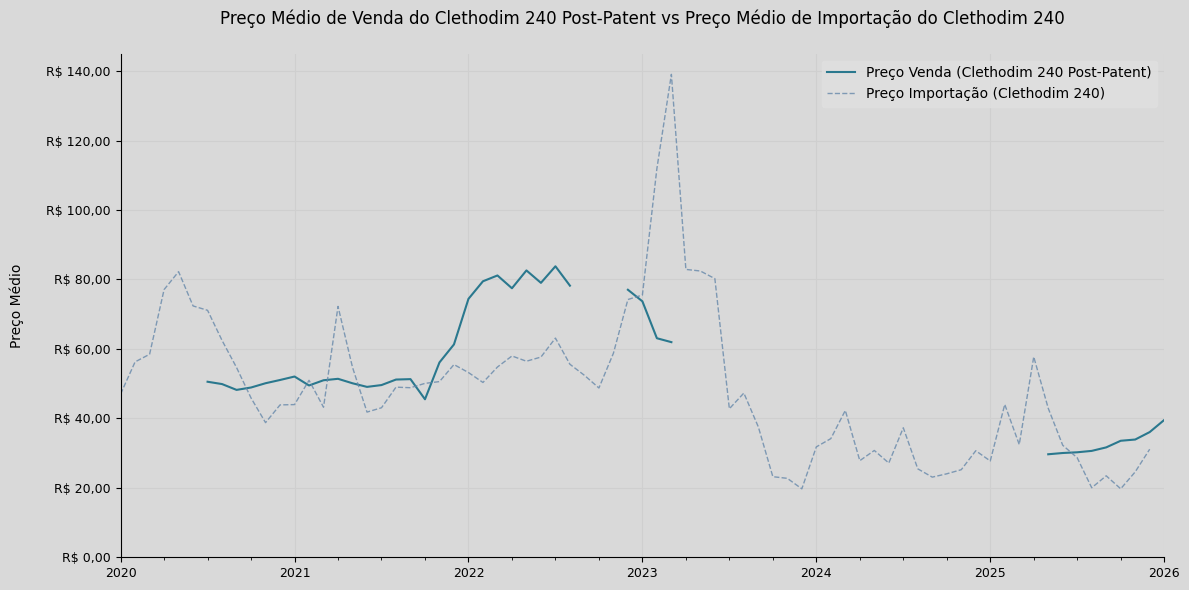

In [87]:
set_plot_style()

min_date = preco_4440['ano_mes'].min()
calendario_completo = pd.date_range(
    start = min_date,
    end = preco_4440['ano_mes'].max(),
    freq = 'MS'
)
preco_4440 = preco_4440.set_index('ano_mes').reindex(calendario_completo)

ax = preco_4440['preco_venda_brl'].plot(color = corViridis[2], label='Preço Venda (Clethodim 240 Post-Patent)')
preco_2734.set_index('ano_mes')['preco_import_brl'].plot(ax = ax, color = corDefault, alpha = 0.8, linewidth = 1, linestyle = '--', label='Preço Importação (Clethodim 240)')
ax.set_title('Preço Médio de Venda do Clethodim 240 Post-Patent vs Preço Médio de Importação do Clethodim 240\n')
ax.grid(axis='both', color = '0.81')
ax.set_xlabel("")
ax.set_ylabel("Preço Médio\n")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')))
ax.tick_params(axis='both', labelsize=9)
ax.set_ylim(bottom = 0)
ax.legend(loc='upper right', facecolor='0.88', edgecolor='0.88')

plt.gcf().set_size_inches(12, 6)
plt.tight_layout()
plt.show()
plt.close()

O `Clethodim 240 Post-Patent` representa um agregado de marcas de Clethodim. A série apresenta um gap pequeno em 2022 e outro de 24 meses (Abril de 2023 a Abril de 2025), impossibilitando análise detalhada de tendência e sazonalidade. No período anterior ao gap, o produto seguiu dinâmica similar ao Poquer, com estabilidade até 2021, escalada até aproximadamente 80 BRL em 2022, e início de queda no primeiro trimestre de 2023. Após o retorno em 2025, o preço de venda se encontra menor que antes da escalada, mostrando uma tendência de crescimento.

## **CORRELAÇÃO ENTRE PREÇO DE IMPORTAÇÃO E PREÇO DE VENDA**

Para explorar a relação entre a variação do preço de importação das moléculas e a variação do preço praticado nos canais de distribuição, irei calculadar três métricas de variação de preço:
- Variação percentual mensal;
- Retorno logarítmico;
- Variação percentual em relação a 3 e 6 meses anteriores.

Dois produtos foram excluídos da análise: `Clethodim 240 Post-Patent` e `Glyphosate AE 720 Post-Patent`.
<br>Ambos apresentam descontinuidades significativas nas séries temporais, o que inviabiliza o cálculo de variações mensais consistentes.
<br>As moléculas correspondentes permanecem representadas pelos demais produtos (`Poquer` para Clethodim; `Roundup WG` e `Zapp QI 620` para Glyphosate).

A análise será conduzida em duas etapas:
1. Agregando os dados por ingrediente ativo (molécula) para maximizar o número de observações;
2. Validação dos resultados por produto individual através de testes de significância estatística.

Além disso, para capturar possíveis defasagens no repasse de custos ao longo da cadeia, será empregada a função de correlação cruzada, avaliando lags de 0 a 6 meses entre as variações do preço de importação e do preço de venda.

In [88]:
precosdf_backup = precosdf.copy()

In [89]:
precosdf = precosdf_backup.copy()

In [90]:
precosdf = precosdf[(precosdf['IdProduto'] != 4554) & (precosdf['IdProduto'] != 4440)].copy().reset_index(drop = True)

precosdf['ano_mes_'] = pd.to_datetime(precosdf["ano_mes"] + "-01")
precosdf = precosdf[precosdf['ano_mes_'] < '2026-01-01'].copy().reset_index(drop = True)
precosdf = precosdf.sort_values(['IdProduto', 'ano_mes_']).reset_index(drop = True)

# TARGET
precosdf['var_pct_venda'] = precosdf.groupby('IdProduto')['preco_venda_brl'].pct_change()

precosdf['var_pct_import'] = precosdf.groupby('IdProduto')['preco_import_brl'].pct_change()
precosdf['var_log_import'] = np.log1p(precosdf['var_pct_import'])
precosdf['var_pct_3m_import'] = precosdf.groupby('IdProduto')['preco_import_brl'].pct_change(periods = 3)
precosdf['var_pct_6m_import'] = precosdf.groupby('IdProduto')['preco_import_brl'].pct_change(periods = 6)

precosdf

,ano_mes,IdProduto,preco_venda_brl,NomeMQEstat,GrupoIA,preco_import_brl,ano_mes_,var_pct_venda,var_pct_import,var_log_import,var_pct_3m_import,var_pct_6m_import
0,2020-01,35,14.829723,Aminol 806,"2,4-D AE 670",10.66,2020-01-01,NaN,NaN,NaN,NaN,NaN
1,2020-02,35,14.804520,Aminol 806,"2,4-D AE 670",8.94,2020-02-01,-0.001699,-0.161351,-0.175963,NaN,NaN
2,2020-03,35,15.209858,Aminol 806,"2,4-D AE 670",11.85,2020-03-01,0.027379,0.325503,0.281792,NaN,NaN
3,2020-04,35,16.183031,Aminol 806,"2,4-D AE 670",11.52,2020-04-01,0.063983,-0.027848,-0.028243,0.080675,NaN
4,2020-05,35,16.705282,Aminol 806,"2,4-D AE 670",12.66,2020-05-01,0.032272,0.098958,0.094363,0.416107,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
571,2025-08,3026,28.720803,Unizeb Gold,MANCOZEB 750,16.10,2025-08-01,0.017945,-0.075244,-0.078225,-0.126898,-0.216926
572,2025-09,3026,29.271054,Unizeb Gold,MANCOZEB 750,17.74,2025-09-01,0.019159,0.101863,0.097003,-0.074596,-0.172960
573,2025-10,3026,29.429231,Unizeb Gold,MANCOZEB 750,17.37,2025-10-01,0.005404,-0.020857,-0.021077,-0.002298,-0.087231
574,2025-11,3026,29.657363,Unizeb Gold,MANCOZEB 750,18.11,2025-11-01,0.007752,0.042602,0.041720,0.124845,-0.017896


In [91]:
var_df = precosdf.groupby(['GrupoIA', 'ano_mes_']).agg({
    'var_pct_venda': 'mean',
    'var_pct_import': 'mean',
    'var_pct_3m_import': 'mean',
    'var_pct_6m_import': 'mean'
}).reset_index()

var_df['var_log_import'] = np.log1p(var_df['var_pct_import'])

var_df

,GrupoIA,ano_mes_,var_pct_venda,var_pct_import,var_pct_3m_import,var_pct_6m_import,var_log_import
0,"2,4-D AE 670",2020-01-01,NaN,NaN,NaN,NaN,NaN
1,"2,4-D AE 670",2020-02-01,0.004773,-0.161351,NaN,NaN,-0.175963
2,"2,4-D AE 670",2020-03-01,0.009692,0.325503,NaN,NaN,0.281792
3,"2,4-D AE 670",2020-04-01,0.056375,-0.027848,0.080675,NaN,-0.028243
4,"2,4-D AE 670",2020-05-01,0.036912,0.098958,0.416107,NaN,0.094363
...,...,...,...,...,...,...,...
283,MANCOZEB 750,2025-08-01,-0.002158,-0.075244,-0.126898,-0.216926,-0.078225
284,MANCOZEB 750,2025-09-01,0.031639,0.101863,-0.074596,-0.172960,0.097003
285,MANCOZEB 750,2025-10-01,0.011114,-0.020857,-0.002298,-0.087231,-0.021077
286,MANCOZEB 750,2025-11-01,0.014845,0.042602,0.124845,-0.017896,0.041720


In [92]:
features = ['var_pct_import', 'var_pct_3m_import', 'var_pct_6m_import', 'var_log_import']

### **FUNÇÃO PARA CALCULAR CCF COM CORRELAÇÃO PEARSON E CORRELAÇÃO SPEARMAN**

In [93]:
def calcular_ccf(df, features, target):
    resultados = []
    
    for feature in features:
        for lag in range(7):
            if lag == 0:
                df_temp = df[[feature, target]].dropna()
                x = df_temp[feature].values
                y = df_temp[target].values
            else:
                df_temp = df[[feature, target]].copy()
                df_temp[f'{feature}_lag'] = df_temp[feature].shift(lag)
                df_temp = df_temp.dropna()
                x = df_temp[f'{feature}_lag'].values
                y = df_temp[target].values
            
            pearson, pearson_pvalue = stats.pearsonr(x, y)
            spearman, spearman_pvalue = stats.spearmanr(x, y)
            
            resultados.append({
                'feature': feature,
                'lag': lag,
                'n': len(x),
                'pearson': pearson,
                'pearson_pvalue': pearson_pvalue,
                'spearman': spearman,
                'spearman_pvalue': spearman_pvalue
            })
    
    return pd.DataFrame(resultados)

### **2,4-D AE 670**

#### **CORRELAÇÃO AGREGADA**

In [94]:
df = var_df[var_df['GrupoIA'] == "2,4-D AE 670"].sort_values('ano_mes_').reset_index(drop = True)

ccf_24d = calcular_ccf(df, features, 'var_pct_venda')
ccf_24d.sort_values('pearson', ascending = False)

,feature,lag,n,pearson,pearson_pvalue,spearman,spearman_pvalue
14,var_pct_6m_import,0,66,0.408622,0.000659,0.463229,0.000090
7,var_pct_3m_import,0,69,0.371251,0.001686,0.342090,0.004014
8,var_pct_3m_import,1,68,0.369412,0.001934,0.319540,0.007903
15,var_pct_6m_import,1,65,0.326634,0.007917,0.371984,0.002280
22,var_log_import,1,70,0.320712,0.006792,0.322404,0.006490
1,var_pct_import,1,70,0.308561,0.009353,0.322404,0.006490
9,var_pct_3m_import,2,67,0.214463,0.081375,0.198380,0.107553
21,var_log_import,0,71,0.202970,0.089580,0.227968,0.055869
16,var_pct_6m_import,2,64,0.198914,0.115086,0.233471,0.063353
0,var_pct_import,0,71,0.189914,0.112668,0.227968,0.055869


In [95]:
ccf_24d[(ccf_24d['pearson_pvalue'] <= 0.05) | (ccf_24d['spearman_pvalue'] <= 0.05)].sort_values('pearson', ascending = False)

,feature,lag,n,pearson,pearson_pvalue,spearman,spearman_pvalue
14,var_pct_6m_import,0,66,0.408622,0.000659,0.463229,0.000090
7,var_pct_3m_import,0,69,0.371251,0.001686,0.342090,0.004014
8,var_pct_3m_import,1,68,0.369412,0.001934,0.319540,0.007903
15,var_pct_6m_import,1,65,0.326634,0.007917,0.371984,0.002280
22,var_log_import,1,70,0.320712,0.006792,0.322404,0.006490
1,var_pct_import,1,70,0.308561,0.009353,0.322404,0.006490


Vemos que a feature com maior correlação com a variação do preço de venda é a variação percentual do preço de importação em relação a 6 meses anteriores (`var_pct_6m_import`) com lag 0, ou seja, sem defasagem.
<br>Isso indica que a variação do preço de venda está mais correlacionada com mudanças de médio prazo (3-6 meses) no preço de importação do que com flutuações mensais, sugerindo que distribuidores reagem a tendências persistentes, não a oscilações pontuais.

A proximidade entre as correlações de Pearson e Spearman indica que a relação é aproximadamente linear.
<br>O valor significativo (p < 0.001), porém moderado (r ≈ 0.41), sugere que outras variáveis externas são importantes para explicar a dinâmica completa do preço de venda.

#### **CORRELAÇÃO POR PRODUTO**

In [96]:
prods = precosdf[precosdf['GrupoIA'] == '2,4-D AE 670']['NomeMQEstat'].unique()

ccf_prod_24D = pd.DataFrame()

for produto in prods:
    df = precosdf[precosdf['NomeMQEstat'] == produto].sort_values('ano_mes_').reset_index(drop = True)
    df = calcular_ccf(df, features, 'var_pct_venda')
    df['NomeMQEstat'] = produto

    ccf_prod_24D = pd.concat([ccf_prod_24D, df], axis = 0, ignore_index = True)

ccf_prod_24D = ccf_prod_24D[(ccf_prod_24D['pearson_pvalue'] <= 0.05) | (ccf_prod_24D['spearman_pvalue'] <= 0.05)].sort_values(['NomeMQEstat', 'pearson'], ascending = [True, False]).reset_index(drop = True)
ccf_prod_24D

,feature,lag,n,pearson,pearson_pvalue,spearman,spearman_pvalue,NomeMQEstat
0,var_pct_3m_import,0,69,0.203255,0.093924,0.437304,0.000172,2 4-D Nortox
1,var_log_import,0,71,0.198233,0.097483,0.317438,0.006987,2 4-D Nortox
2,var_pct_6m_import,0,66,0.197304,0.112302,0.414132,0.000547,2 4-D Nortox
3,var_pct_import,0,71,0.186645,0.119112,0.317438,0.006987,2 4-D Nortox
4,var_pct_3m_import,1,68,0.099795,0.418112,0.242585,0.046239,2 4-D Nortox
5,var_pct_6m_import,1,65,0.097398,0.440205,0.257474,0.038397,2 4-D Nortox
6,var_pct_6m_import,0,66,0.431351,0.000299,0.495168,0.000024,Aminol 806
7,var_pct_3m_import,0,69,0.389069,0.000953,0.340190,0.004236,Aminol 806
8,var_pct_3m_import,1,68,0.385295,0.001176,0.322976,0.007224,Aminol 806
9,var_log_import,1,70,0.322990,0.006388,0.312431,0.008459,Aminol 806


In [97]:
precosdf[precosdf['GrupoIA'] == '2,4-D AE 670'][['var_pct_venda', 'var_pct_import', 'var_log_import', 'var_pct_3m_import', 'var_pct_6m_import']].corr()[['var_pct_venda']]

,var_pct_venda
var_pct_venda,1.000000
var_pct_import,0.136164
var_log_import,0.145524
var_pct_3m_import,0.266259
var_pct_6m_import,0.290266


A análise por produto revela que todos os três produtos de 2,4-D apresentam correlação significativa entre a variação do preço de importação e a variação do preço de venda, indicando boas perspectivas para um modelo preditivo no nível de produto, sem necessidade de agregação por molécula.

A diferença na magnitude das correlações entre produtos (Aminol 806 com r ≈ 0.43 vs 2 4-D Nortox com r ≈ 0.20) sugere diferentes estratégias de precificação, possivelmente relacionadas ao posicionamento de mercado de cada marca. Essa heterogeneidade reforça a necessidade de variáveis categóricas que permitam ao modelo distinguir entre produtos e identificar o mercado ou cultura-alvo de cada um.

Além disso, o valor moderado das correlações (r < 0.5) confirma a importância de incorporar features externas que capturem a dinâmica do mercado.

### **GLYPHOSATE AE 500/720**

#### **CORRELAÇÃO AGREGADA**

In [98]:
df = var_df[var_df['GrupoIA'] == "GLYPHOSATE AE 500/720"].sort_values('ano_mes_').reset_index(drop = True)

ccf_glif = calcular_ccf(df, features, 'var_pct_venda')
ccf_glif.sort_values('pearson', ascending = False)

,feature,lag,n,pearson,pearson_pvalue,spearman,spearman_pvalue
7,var_pct_3m_import,0,69,0.553045,8.312581e-07,0.559664,5.751715e-07
14,var_pct_6m_import,0,66,0.485222,3.639964e-05,0.377309,1.790106e-03
0,var_pct_import,0,71,0.438972,1.284003e-04,0.313280,7.809167e-03
8,var_pct_3m_import,1,68,0.422035,3.374735e-04,0.491430,2.086076e-05
21,var_log_import,0,71,0.421116,2.551526e-04,0.313280,7.809167e-03
1,var_pct_import,1,70,0.372394,1.500478e-03,0.396238,6.847736e-04
22,var_log_import,1,70,0.363900,1.956848e-03,0.396238,6.847736e-04
15,var_pct_6m_import,1,65,0.341899,5.311101e-03,0.245979,4.825361e-02
9,var_pct_3m_import,2,67,0.280317,2.158538e-02,0.333865,5.760993e-03
23,var_log_import,2,69,0.276885,2.126792e-02,0.362952,2.176116e-03


In [99]:
ccf_glif[(ccf_glif['pearson_pvalue'] <= 0.05) | (ccf_glif['spearman_pvalue'] <= 0.05)].sort_values('pearson', ascending = False)

,feature,lag,n,pearson,pearson_pvalue,spearman,spearman_pvalue
7,var_pct_3m_import,0,69,0.553045,8.312581e-07,0.559664,5.751715e-07
14,var_pct_6m_import,0,66,0.485222,3.639964e-05,0.377309,1.790106e-03
0,var_pct_import,0,71,0.438972,1.284003e-04,0.313280,7.809167e-03
8,var_pct_3m_import,1,68,0.422035,3.374735e-04,0.491430,2.086076e-05
21,var_log_import,0,71,0.421116,2.551526e-04,0.313280,7.809167e-03
1,var_pct_import,1,70,0.372394,1.500478e-03,0.396238,6.847736e-04
22,var_log_import,1,70,0.363900,1.956848e-03,0.396238,6.847736e-04
15,var_pct_6m_import,1,65,0.341899,5.311101e-03,0.245979,4.825361e-02
9,var_pct_3m_import,2,67,0.280317,2.158538e-02,0.333865,5.760993e-03
23,var_log_import,2,69,0.276885,2.126792e-02,0.362952,2.176116e-03


Para o Glyphosate, a feature com maior correlação é a variação percentual do preço de importação em relação a 3 meses anteriores (`var_pct_3m_import`) com lag 0, apresentando r = 0.55 (p < 0.001).
<br>Diferentemente do 2,4-D, cuja melhor janela foi de 6 meses, o Glyphosate responde a uma janela mais curta. Então, variações de custo são repassadas mais rapidamente.

A correlação moderada-forte, indica que, através de r² ≈ 0.30, cerca de 30% da variância do preço de venda é explicada pela variação do preço de importação.
<br>A proximidade entre Pearson e Spearman confirma a linearidade da relação.
<br>Assim como no 2,4-D, o valor ainda moderado reforça a necessidade de features externas para capturar a dinâmica completa.

#### **CORRELAÇÃO POR PRODUTO**

In [100]:
prods = precosdf[precosdf['GrupoIA'] == 'GLYPHOSATE AE 500/720']['NomeMQEstat'].unique()

ccf_prod_glif = pd.DataFrame()

for produto in prods:
    df = precosdf[precosdf['NomeMQEstat'] == produto].sort_values('ano_mes_').reset_index(drop = True)
    df = calcular_ccf(df, features, 'var_pct_venda')
    df['NomeMQEstat'] = produto

    ccf_prod_glif = pd.concat([ccf_prod_glif, df], axis = 0, ignore_index = True)

ccf_prod_glif = ccf_prod_glif[(ccf_prod_glif['pearson_pvalue'] <= 0.05) | (ccf_prod_glif['spearman_pvalue'] <= 0.05)].sort_values(['NomeMQEstat', 'pearson'], ascending = [True, False]).reset_index(drop = True)
ccf_prod_glif

,feature,lag,n,pearson,pearson_pvalue,spearman,spearman_pvalue,NomeMQEstat
0,var_pct_3m_import,0,69,0.533588,2.346833e-06,0.529010,2.968359e-06,Roundup WG
1,var_pct_6m_import,0,66,0.472194,6.259473e-05,0.411335,6.011944e-04,Roundup WG
2,var_pct_import,0,71,0.432846,1.632145e-04,0.314789,7.501579e-03,Roundup WG
3,var_log_import,0,71,0.419725,2.687507e-04,0.314789,7.501579e-03,Roundup WG
4,var_pct_3m_import,1,68,0.390013,1.009956e-03,0.482498,3.089730e-05,Roundup WG
5,var_pct_import,1,70,0.354229,2.625152e-03,0.371429,1.547026e-03,Roundup WG
6,var_log_import,1,70,0.345938,3.353196e-03,0.371429,1.547026e-03,Roundup WG
7,var_pct_6m_import,1,65,0.341226,5.407731e-03,0.313112,1.109740e-02,Roundup WG
8,var_pct_3m_import,2,67,0.264998,3.022042e-02,0.328957,6.566804e-03,Roundup WG
9,var_log_import,2,69,0.259378,3.138354e-02,0.312642,8.910495e-03,Roundup WG


In [101]:
precosdf[precosdf['GrupoIA'] == 'GLYPHOSATE AE 500/720'][['var_pct_venda', 'var_pct_import', 'var_log_import', 'var_pct_3m_import', 'var_pct_6m_import']].corr()[['var_pct_venda']]

,var_pct_venda
var_pct_venda,1.000000
var_pct_import,0.430192
var_log_import,0.412692
var_pct_3m_import,0.542112
var_pct_6m_import,0.476288


A análise por produto confirma o padrão agregado: tanto `Roundup WG` (r = 0.53) quanto `Zapp QI 620` (r = 0.55) apresentam a maior correlação com `var_pct_3m_import` em lag 0.

A similaridade entre as correlações dos dois produtos contrasta com a heterogeneidade observada nos produtos 2,4-D.
<br>Assim como no 2,4-D, os resultados indicam viabilidade de modelagem no nível de produto.

### **MANCOZEB 750**

#### **CORRELAÇÃO AGREGADA**

In [102]:
df = var_df[var_df['GrupoIA'] == "MANCOZEB 750"].sort_values('ano_mes_').reset_index(drop = True)

ccf_mancoz = calcular_ccf(df, features, 'var_pct_venda')
ccf_mancoz.sort_values('pearson', ascending = False)

,feature,lag,n,pearson,pearson_pvalue,spearman,spearman_pvalue
11,var_pct_3m_import,4,65,0.246015,0.048220,0.292483,0.018066
10,var_pct_3m_import,3,66,0.176721,0.155766,0.199750,0.107831
25,var_log_import,4,67,0.166744,0.177453,0.168689,0.172381
12,var_pct_3m_import,5,64,0.162620,0.199183,0.160211,0.206011
4,var_pct_import,4,67,0.158294,0.200759,0.168689,0.172381
15,var_pct_6m_import,1,65,0.152139,0.226339,0.193663,0.122168
16,var_pct_6m_import,2,64,0.148878,0.240352,0.185668,0.141866
5,var_pct_import,5,66,0.122415,0.327486,0.078551,0.530705
26,var_log_import,5,66,0.095543,0.445397,0.078551,0.530705
6,var_pct_import,6,65,0.084909,0.501270,0.110358,0.381492


In [103]:
ccf_mancoz[(ccf_mancoz['pearson_pvalue'] <= 0.05) | (ccf_mancoz['spearman_pvalue'] <= 0.05)].sort_values('pearson', ascending = False)

,feature,lag,n,pearson,pearson_pvalue,spearman,spearman_pvalue
11,var_pct_3m_import,4,65,0.246015,0.048220,0.292483,0.018066
20,var_pct_6m_import,6,60,-0.287350,0.026004,-0.231787,0.074750


O Mancozebe apresenta um padrão distinto das demais moléculas: apenas duas combinações com significância estatística, correlações fracas (r ≈ 0.25) e lags mais longos (4-6 meses).
<br>Esse resultado é consistente com a análise de tendências, onde identificamos que a UPL, possui integração vertical com fábricas na Índia, absorvendo variações de custo ao invés de repassá-las diretamente.

Como a correlação é baixa, as features de preço de importação explicam muito pouco da variância do preço de venda, tornando indispensável a inclusão de variáveis externas para um modelo preditivo viável.

#### **CORRELAÇÃO POR PRODUTO**

In [104]:
prods = precosdf[precosdf['GrupoIA'] == 'MANCOZEB 750']['NomeMQEstat'].unique()

ccf_prod_mancoz = pd.DataFrame()

for produto in prods:
    df = precosdf[precosdf['NomeMQEstat'] == produto].sort_values('ano_mes_').reset_index(drop = True)
    df = calcular_ccf(df, features, 'var_pct_venda')
    df['NomeMQEstat'] = produto

    ccf_prod_mancoz = pd.concat([ccf_prod_mancoz, df], axis = 0, ignore_index = True)

ccf_prod_mancoz = ccf_prod_mancoz[(ccf_prod_mancoz['pearson_pvalue'] <= 0.05) | (ccf_prod_mancoz['spearman_pvalue'] <= 0.05)].sort_values(['NomeMQEstat', 'pearson'], ascending = [True, False]).reset_index(drop = True)
ccf_prod_mancoz

,feature,lag,n,pearson,pearson_pvalue,spearman,spearman_pvalue,NomeMQEstat
0,var_pct_3m_import,4,65,0.209122,0.094559,0.254240,0.040985,Manzate 750 WG
1,var_pct_3m_import,4,65,0.237874,0.056381,0.248689,0.045761,Unizeb Gold
2,var_pct_6m_import,6,60,-0.314120,0.014518,-0.283801,0.027987,Unizeb Gold


In [105]:
precosdf[precosdf['GrupoIA'] == 'MANCOZEB 750'][['var_pct_venda', 'var_pct_import', 'var_log_import', 'var_pct_3m_import', 'var_pct_6m_import']].corr()[['var_pct_venda']]

,var_pct_venda
var_pct_venda,1.000000
var_pct_import,-0.123565
var_log_import,-0.114278
var_pct_3m_import,-0.136016
var_pct_6m_import,0.035806


A análise por produto confirma a baixa correlação. O `Manzate 750 WG` não apresenta nenhuma combinação significativa em Pearson (p-value = 0.09), sendo marginalmente significativa apenas em Spearman. Já o `Unizeb Gold` possui apenas uma combinação significativa em ambos os testes (`var_pct_6m_import` com lag 6), e esta é negativa (r = -0.31). Isso reforça a hipótese de que a UPL, com a integração vertical, consegue absorver variações de custo ao invés de repassá-las.

Para esta molécula, um modelo preditivo baseado apenas em preço de importação seria insuficiente, exigindo features externas como indicadores de demanda agrícola, estoques e condições climáticas.

Para este caso, diferentemente do 2,4-D e Glyphosate, um modelo preditivo no nível agregado (molécula) pode ser mais adequado, reduzindo ruído e capturando melhor o sinal.
<br>Posteriormente, técnicas de desagregação poderiam distribuir as previsões para o nível de produto.
<br>Independente da abordagem, features externas serão indispensáveis.

### **CLETHODIM 240**

In [106]:
df = var_df[var_df['GrupoIA'] == "CLETHODIM 240"].sort_values('ano_mes_').reset_index(drop = True)

ccf_cletod = calcular_ccf(df, features, 'var_pct_venda')
ccf_cletod['NomeMQEstat'] = precosdf[precosdf['GrupoIA'] == "CLETHODIM 240"]['NomeMQEstat'].iloc[0]
ccf_cletod.sort_values('pearson', ascending = False)

,feature,lag,n,pearson,pearson_pvalue,spearman,spearman_pvalue,NomeMQEstat
21,var_log_import,0,71,0.094589,0.432667,0.039269,0.745076,Poquer
0,var_pct_import,0,71,0.057934,0.631302,0.039269,0.745076,Poquer
22,var_log_import,1,70,0.022478,0.853465,-0.037984,0.754895,Poquer
23,var_log_import,2,69,0.014375,0.906673,-0.073986,0.545726,Poquer
20,var_pct_6m_import,6,60,0.012907,0.922030,0.073409,0.577242,Poquer
7,var_pct_3m_import,0,69,0.007703,0.949911,-0.002448,0.984073,Poquer
1,var_pct_import,1,70,-0.004588,0.969930,-0.037984,0.754895,Poquer
2,var_pct_import,2,69,-0.026503,0.828860,-0.073986,0.545726,Poquer
8,var_pct_3m_import,1,68,-0.062255,0.614025,-0.096271,0.434823,Poquer
24,var_log_import,3,68,-0.080138,0.515934,-0.120510,0.327629,Poquer


In [107]:
ccf_cletod[(ccf_cletod['pearson_pvalue'] <= 0.05) | (ccf_cletod['spearman_pvalue'] <= 0.05)].sort_values('pearson', ascending = True)

,feature,lag,n,pearson,pearson_pvalue,spearman,spearman_pvalue,NomeMQEstat
17,var_pct_6m_import,3,63,-0.340246,0.006363,-0.129608,0.311341,Poquer
16,var_pct_6m_import,2,64,-0.323631,0.009090,-0.255174,0.041853,Poquer
11,var_pct_3m_import,4,65,-0.302012,0.014483,-0.182343,0.146005,Poquer
15,var_pct_6m_import,1,65,-0.276710,0.025656,-0.263942,0.033627,Poquer
10,var_pct_3m_import,3,66,-0.257362,0.036965,-0.169941,0.172514,Poquer


O Clethodim apresenta correlações negativas (r entre -0.26 e -0.34) com lags de 1 a 4 meses. A divergência entre Pearson (significativo) e Spearman (nem sempre significativo) sugere possível influência de outliers ou relação não-linear.
<br>No entanto, esses resultados devem ser interpretados com cautela, pois conforme identificado na etapa de importação de dados via NCM, os códigos utilizados para importação de Clethodim (38.08.93.2.9 e 29.30.90.3.9) agregam múltiplas moléculas, comprometendo a representatividade do preço de importação.

Para esta molécula, a construção de um modelo preditivo confiável exigiria estudo mais aprofundado para entender como melhor obter informações de importação